# **Machine learning approach to predict Citi Bike rental demand using Weather data**


<img src="citibike_demand.jpg" width="500" height="300">


This project aims to predict and forecast hourly bike rental demand using weather conditions. The goal is to provide accurate demand forecasts for bike-sharing companies to optimize their operations and inventory management.

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Datasets


The datasets comprises:


1.   Bike Sharing Data: Contains Citi Bike data which contains information about ride ids, locations, ride start times, end times, and stations.
2.
Weather Data: Temperature, humidity, solar radiation, wind speed, precipitation, and dew point.  





The data is sourced from:


*   
 Bike-sharing companies' official datasets (CitiBike)
*    Visual Crossing Weather API for weather data.




### Newyork Weather data

In [62]:
NY_Weather_file_path = "NewYorkWeather.csv"

weatherDataNYC = pd.read_csv(NY_Weather_file_path)

In [63]:
weatherDataNYC.head()

,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,"New York, NY, United States",2023-04-01T00:00:00,12.0,12.0,7.6,74.40,0.0,0,NaN,0.0,0.0,25.9,3.0,61,1012.0,100.0,16.0,0,0.0,0,10,Overcast,cloudy,"72505394728,KEWR,KLGA,72502014734,KNYC,7250301..."
1,"New York, NY, United States",2023-04-01T01:00:00,13.2,13.2,7.9,70.22,0.0,0,NaN,0.0,0.0,25.9,9.5,235,1011.2,100.0,16.0,0,0.0,0,10,Overcast,cloudy,"72505394728,KEWR,KLGA,72502014734,KNYC,7250301..."
2,"New York, NY, United States",2023-04-01T02:00:00,14.5,14.5,7.7,63.70,0.0,0,NaN,0.0,0.0,24.1,8.4,235,1010.0,100.0,16.0,0,0.0,0,10,Overcast,cloudy,"72505394728,KEWR,KLGA,72502014734,KNYC,7250301..."
3,"New York, NY, United States",2023-04-01T03:00:00,15.3,15.3,9.0,65.84,0.0,0,NaN,0.0,0.0,35.3,11.7,178,1008.4,100.0,16.0,0,0.0,0,10,Overcast,cloudy,"72505394728,KEWR,KLGA,72502014734,KNYC,7250301..."
4,"New York, NY, United States",2023-04-01T04:00:00,14.3,14.3,9.2,71.52,0.0,0,NaN,0.0,0.0,24.1,7.3,93,1007.2,100.0,15.3,0,0.0,0,10,Overcast,cloudy,"72505394728,KEWR,KLGA,72502014734,KNYC,7250301..."


### CitibikeNYC data

In [64]:
import os
import pandas as pd

def combine_csv_files_local(folder_path):
    """
    Combine all CSV files in a specified local folder into a single DataFrame.

    Parameters:
    folder_path (str): Path to the folder containing the CSV files.

    Returns:
    pd.DataFrame: Combined DataFrame containing all data from the CSV files.
    """
    combined_data = pd.DataFrame()

    # Iterate through all files in the folder
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):  # Check if the file is a CSV
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            combined_data = pd.concat([combined_data, df], ignore_index=True)
    
    return combined_data

citibike_folder_path = "citibike"

citibikeNYCData = combine_csv_files_local(citibike_folder_path)

# Print the first few rows of the combined data as a check
print(citibikeNYCData.head())


            ride_id  rideable_type           started_at             ended_at  \
0  59B1078FC3455D5B  electric_bike  2023-04-02 14:50:55  2023-04-02 15:01:24   
1  84365D599B6E002E  electric_bike  2023-04-15 21:08:54  2023-04-16 10:54:44   
2  A4F033EAA7810781   classic_bike  2023-04-17 10:35:11  2023-04-17 10:37:53   
3  E9051DFD91E516BF   classic_bike  2023-04-07 12:19:31  2023-04-07 12:21:52   
4  0F6D86AEC1B29205   classic_bike  2023-04-07 12:28:21  2023-04-07 12:30:23   

  start_station_name start_station_id  end_station_name end_station_id  \
0      Hamilton Park            JC009     Hamilton Park          JC009   
1      Hamilton Park            JC009     Hamilton Park          JC009   
2      Hamilton Park            JC009  Monmouth and 6th          JC075   
3      Hamilton Park            JC009  Monmouth and 6th          JC075   
4      Hamilton Park            JC009  Monmouth and 6th          JC075   

   start_lat  start_lng    end_lat    end_lng member_casual  
0  40.727596

In [65]:
citibikeNYCData.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,59B1078FC3455D5B,electric_bike,2023-04-02 14:50:55,2023-04-02 15:01:24,Hamilton Park,JC009,Hamilton Park,JC009,40.727596,-74.044247,40.727596,-74.044247,member
1,84365D599B6E002E,electric_bike,2023-04-15 21:08:54,2023-04-16 10:54:44,Hamilton Park,JC009,Hamilton Park,JC009,40.727596,-74.044247,40.727596,-74.044247,casual
2,A4F033EAA7810781,classic_bike,2023-04-17 10:35:11,2023-04-17 10:37:53,Hamilton Park,JC009,Monmouth and 6th,JC075,40.727596,-74.044247,40.725685,-74.048790,member
3,E9051DFD91E516BF,classic_bike,2023-04-07 12:19:31,2023-04-07 12:21:52,Hamilton Park,JC009,Monmouth and 6th,JC075,40.727596,-74.044247,40.725685,-74.048790,member
4,0F6D86AEC1B29205,classic_bike,2023-04-07 12:28:21,2023-04-07 12:30:23,Hamilton Park,JC009,Monmouth and 6th,JC075,40.727596,-74.044247,40.725685,-74.048790,member


In [66]:
citibikeNYCData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069462 entries, 0 to 1069461
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1069462 non-null  object 
 1   rideable_type       1069462 non-null  object 
 2   started_at          1069462 non-null  object 
 3   ended_at            1069462 non-null  object 
 4   start_station_name  1069277 non-null  object 
 5   start_station_id    1069277 non-null  object 
 6   end_station_name    1065973 non-null  object 
 7   end_station_id      1065944 non-null  object 
 8   start_lat           1069462 non-null  float64
 9   start_lng           1069462 non-null  float64
 10  end_lat             1068580 non-null  float64
 11  end_lng             1068580 non-null  float64
 12  member_casual       1069462 non-null  object 
dtypes: float64(4), object(9)
memory usage: 106.1+ MB


In [67]:
citibikeNYCData.isna().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     185
start_station_id       185
end_station_name      3489
end_station_id        3518
start_lat                0
start_lng                0
end_lat                882
end_lng                882
member_casual            0
dtype: int64

In [68]:
# Dropping the NA values because there aren't any ride for the ones without station names

citibikeNYCData = citibikeNYCData.dropna(subset=['started_at', 'ended_at', 'start_station_name', 'end_station_name'])

In [69]:
citibikeNYCData.isna().sum()

ride_id                0
rideable_type          0
started_at             0
ended_at               0
start_station_name     0
start_station_id       0
end_station_name       0
end_station_id        29
start_lat              0
start_lng              0
end_lat                0
end_lng                0
member_casual          0
dtype: int64

In [70]:
# Columns to drop
columns_to_drop = ['feelslike', 'precipprob', 'preciptype', 'snow', 'snowdepth',
                   'windgust', 'winddir', 'solarenergy', 'uvindex', 'severerisk',
                   'icon', 'stations']

In [71]:
weatherDataNYC = weatherDataNYC.drop(columns=columns_to_drop)
weatherDataNYC.head()

,name,datetime,temp,dew,humidity,precip,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,conditions
0,"New York, NY, United States",2023-04-01T00:00:00,12.0,7.6,74.40,0.0,3.0,1012.0,100.0,16.0,0,Overcast
1,"New York, NY, United States",2023-04-01T01:00:00,13.2,7.9,70.22,0.0,9.5,1011.2,100.0,16.0,0,Overcast
2,"New York, NY, United States",2023-04-01T02:00:00,14.5,7.7,63.70,0.0,8.4,1010.0,100.0,16.0,0,Overcast
3,"New York, NY, United States",2023-04-01T03:00:00,15.3,9.0,65.84,0.0,11.7,1008.4,100.0,16.0,0,Overcast
4,"New York, NY, United States",2023-04-01T04:00:00,14.3,9.2,71.52,0.0,7.3,1007.2,100.0,15.3,0,Overcast


In [72]:
weatherDataNYC.isna().sum()

name                0
datetime            0
temp                0
dew                 0
humidity            0
precip              0
windspeed           0
sealevelpressure    0
cloudcover          0
visibility          0
solarradiation      0
conditions          0
dtype: int64

In [73]:
weatherDataNYC['datetime'] = pd.to_datetime(weatherDataNYC['datetime'], errors='coerce')

In [74]:
#converting time columns to datetime format
citibikeNYCData['started_at'] = pd.to_datetime(citibikeNYCData['started_at'], errors='coerce', format='mixed')
citibikeNYCData['ended_at'] = pd.to_datetime(citibikeNYCData['ended_at'], errors='coerce', format='mixed')

In [75]:
citibikeNYCData['ride_duration'] = (citibikeNYCData['ended_at'] - citibikeNYCData['started_at']).dt.total_seconds()

citibikeNYCData['ride_duration'] = citibikeNYCData['ride_duration'].apply(
    lambda x: f"{int(x // 60)}.{int(x % 60):02d}"
)

In [76]:
citibikeNYCData['started_at'].isna().sum()

0

In [77]:
citibikeNYCData['ended_at'].isna().sum()

0

In [78]:
citibikeNYCData.dtypes

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
ride_duration                 object
dtype: object

In [79]:
#adding started_at_hour column
citibikeNYCData['started_at_hour'] = citibikeNYCData['started_at'].dt.floor('H')

citiBikeNYCMergedData = pd.merge(citibikeNYCData, weatherDataNYC, left_on='started_at_hour', right_on='datetime', how='left')
pd.set_option('display.max_columns', None)
citiBikeNYCMergedData.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,started_at_hour,name,datetime,temp,dew,humidity,precip,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,conditions
0,59B1078FC3455D5B,electric_bike,2023-04-02 14:50:55,2023-04-02 15:01:24,Hamilton Park,JC009,Hamilton Park,JC009,40.727596,-74.044247,40.727596,-74.044247,member,10.29,2023-04-02 14:00:00,"New York, NY, United States",2023-04-02 14:00:00,10.0,-12.0,19.98,0.000,17.8,1014.8,10.5,16.0,886,Clear
1,84365D599B6E002E,electric_bike,2023-04-15 21:08:54,2023-04-16 10:54:44,Hamilton Park,JC009,Hamilton Park,JC009,40.727596,-74.044247,40.727596,-74.044247,casual,825.50,2023-04-15 21:00:00,"New York, NY, United States",2023-04-15 21:00:00,16.4,14.8,90.67,0.128,4.3,1011.6,93.1,5.8,0,"Rain, Overcast"
2,A4F033EAA7810781,classic_bike,2023-04-17 10:35:11,2023-04-17 10:37:53,Hamilton Park,JC009,Monmouth and 6th,JC075,40.727596,-74.044247,40.725685,-74.048790,member,2.42,2023-04-17 10:00:00,"New York, NY, United States",2023-04-17 10:00:00,12.2,11.4,94.66,0.000,9.9,1002.7,100.0,4.2,107,Overcast
3,E9051DFD91E516BF,classic_bike,2023-04-07 12:19:31,2023-04-07 12:21:52,Hamilton Park,JC009,Monmouth and 6th,JC075,40.727596,-74.044247,40.725685,-74.048790,member,2.21,2023-04-07 12:00:00,"New York, NY, United States",2023-04-07 12:00:00,13.4,-8.3,21.41,0.000,15.5,1026.7,38.4,16.0,330,Partially cloudy
4,0F6D86AEC1B29205,classic_bike,2023-04-07 12:28:21,2023-04-07 12:30:23,Hamilton Park,JC009,Monmouth and 6th,JC075,40.727596,-74.044247,40.725685,-74.048790,member,2.02,2023-04-07 12:00:00,"New York, NY, United States",2023-04-07 12:00:00,13.4,-8.3,21.41,0.000,15.5,1026.7,38.4,16.0,330,Partially cloudy


## Exploratory Data Analysis (EDA)

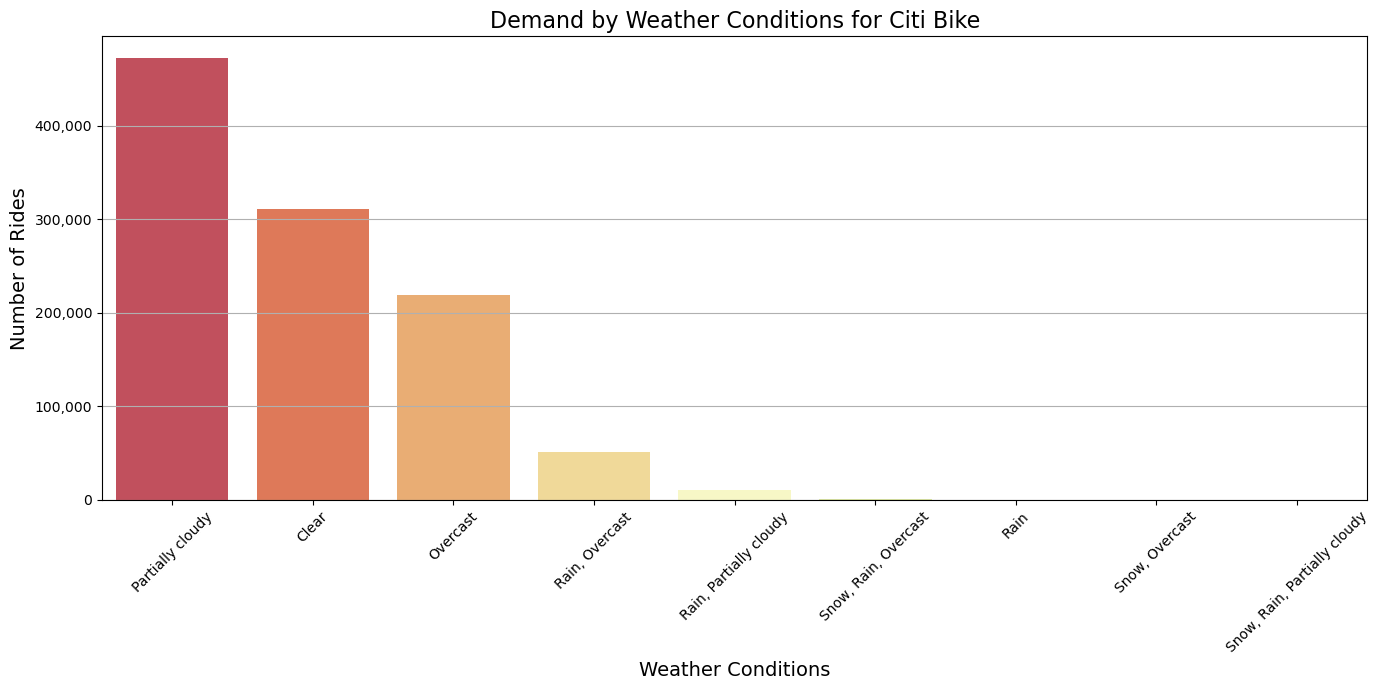

In [80]:
from matplotlib.ticker import FuncFormatter

ride_demand_weather = citiBikeNYCMergedData.groupby('conditions').size().reset_index(name='ride_count')
ride_demand_weather = ride_demand_weather.sort_values(by='ride_count', ascending=False)
plt.figure(figsize=(14, 7))
sns.barplot(data=ride_demand_weather, x='conditions', y='ride_count', palette='Spectral')
plt.title('Demand by Weather Conditions for Citi Bike', fontsize=16)
plt.xlabel('Weather Conditions', fontsize=14)
plt.ylabel('Number of Rides', fontsize=14)
def format_func(value, tick_number):
    return f'{int(value):,}'
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_func))
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Citi Bike Ride Demand by Weather Conditions

The bar chart highlights the relationship between **Citi Bike ride demand** and various weather conditions:

- **Partially cloudy weather** generates the **highest ride demand**, reflecting its appeal for outdoor activities.
- In contrast, **adverse conditions** such as **rain**, **snow**, and **overcast skies** lead to a **significant decrease in ride demand**.


In [81]:
citiBikeNYCMergedData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065968 entries, 0 to 1065967
Data columns (total 27 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1065968 non-null  object        
 1   rideable_type       1065968 non-null  object        
 2   started_at          1065968 non-null  datetime64[ns]
 3   ended_at            1065968 non-null  datetime64[ns]
 4   start_station_name  1065968 non-null  object        
 5   start_station_id    1065968 non-null  object        
 6   end_station_name    1065968 non-null  object        
 7   end_station_id      1065939 non-null  object        
 8   start_lat           1065968 non-null  float64       
 9   start_lng           1065968 non-null  float64       
 10  end_lat             1065968 non-null  float64       
 11  end_lng             1065968 non-null  float64       
 12  member_casual       1065968 non-null  object        
 13  ride_duratio

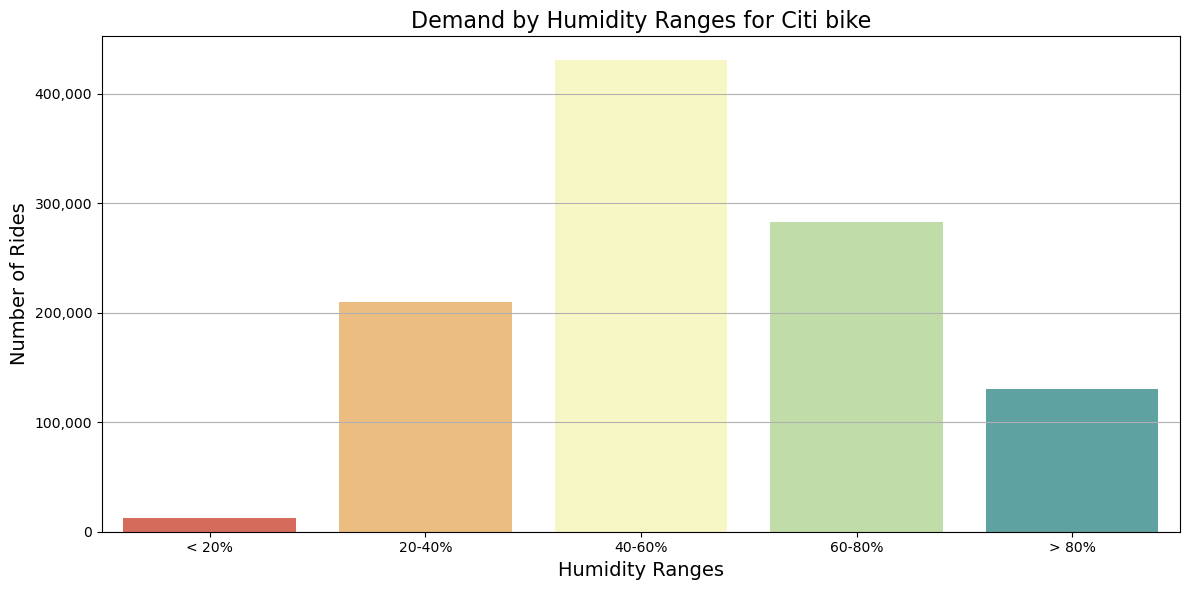

In [82]:
bins = [-float('inf'), 20, 40, 60, 80, 100]
labels = ['< 20%', '20-40%', '40-60%', '60-80%', '> 80%']
citiBikeNYCMergedData['humidity_bins'] = pd.cut(citiBikeNYCMergedData['humidity'], bins=bins, labels=labels)
demand_by_humidity = citiBikeNYCMergedData.groupby('humidity_bins')['ride_id'].count().reset_index()
demand_by_humidity.columns = ['Humidity Ranges', 'Number of Rides']
plt.figure(figsize=(12, 6))
sns.barplot(data=demand_by_humidity, x='Humidity Ranges', y='Number of Rides', palette='Spectral')
plt.title('Demand by Humidity Ranges for Citi bike', fontsize=16)
plt.xlabel('Humidity Ranges', fontsize=14)
plt.ylabel('Number of Rides', fontsize=14)
def format_func(value, tick_number):
    return f'{int(value):,}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_func))

plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Citi Bike Ride Demand by Humidity Levels

The bar chart demonstrates the relationship between **Citi Bike ride demand** and **humidity levels**:

- **Highest demand** is observed when **humidity ranges between 40% and 60%**, a comfortable range for outdoor activities.
- **Significantly lower demand** is seen in conditions of **very low humidity (<20%)** and **very high humidity (>80%)**, likely due to discomfort in extreme conditions.


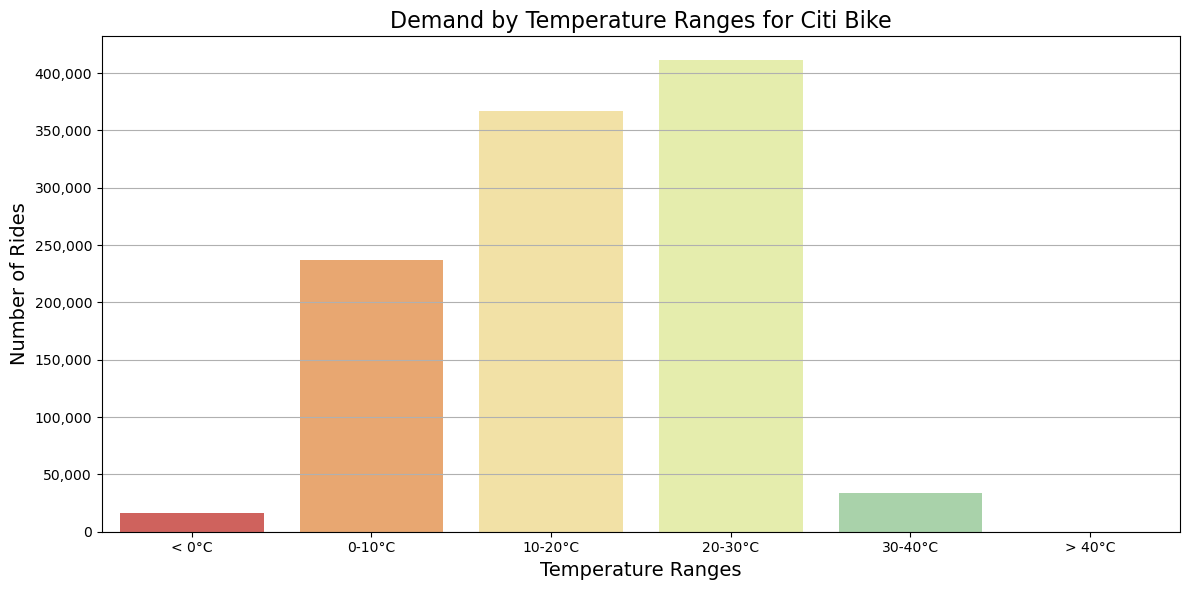

In [83]:
bins = [-float('inf'), 0, 10, 20, 30, 40, float('inf')]
labels = ['< 0°C', '0-10°C', '10-20°C', '20-30°C', '30-40°C', '> 40°C']

citiBikeNYCMergedData['temp_bins'] = pd.cut(citiBikeNYCMergedData['temp'], bins=bins, labels=labels)
demand_by_temp = citiBikeNYCMergedData.groupby('temp_bins')['ride_id'].count().reset_index()
demand_by_temp.columns = ['Temperature Ranges', 'Number of Rides']
plt.figure(figsize=(12, 6))
sns.barplot(data=demand_by_temp, x='Temperature Ranges', y='Number of Rides', palette='Spectral')
plt.title('Demand by Temperature Ranges for Citi Bike', fontsize=16)
plt.xlabel('Temperature Ranges', fontsize=14)
plt.ylabel('Number of Rides', fontsize=14)
def format_func(value, tick_number):
    return f'{int(value):,}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_func))
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Citi Bike Ride Demand by Temperature Ranges

The bar chart highlights the relationship between **Citi Bike ride demand** and **temperature ranges**:

- **Highest demand** is recorded when the **temperature ranges between 20°C and 30°C**, which is ideal for outdoor activities.
- **Significantly lower demand** is observed during **cold temperatures (<10°C)** and **extreme heat (>40°C)**, likely due to reduced comfort levels.


In [84]:
citiBikeNYCMergedData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065968 entries, 0 to 1065967
Data columns (total 29 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1065968 non-null  object        
 1   rideable_type       1065968 non-null  object        
 2   started_at          1065968 non-null  datetime64[ns]
 3   ended_at            1065968 non-null  datetime64[ns]
 4   start_station_name  1065968 non-null  object        
 5   start_station_id    1065968 non-null  object        
 6   end_station_name    1065968 non-null  object        
 7   end_station_id      1065939 non-null  object        
 8   start_lat           1065968 non-null  float64       
 9   start_lng           1065968 non-null  float64       
 10  end_lat             1065968 non-null  float64       
 11  end_lng             1065968 non-null  float64       
 12  member_casual       1065968 non-null  object        
 13  ride_duratio

In [85]:
citiBikeNYCMergedData = citiBikeNYCMergedData.drop(['humidity_bins', 'temp_bins'], axis=1)

In [87]:
#saving the merged csv file as a .csv file
citiBikeNYCMergedData.to_csv('citiBikeNYCMergedData.csv', index=False)

In [88]:
hourly_demand_CitiBike = citiBikeNYCMergedData.groupby('started_at_hour')['ride_id'].count().reset_index()
hourly_demand_CitiBike.columns = ['started_at_hour', 'total_demand']

citiBikeHourlyDataMerged = pd.merge(hourly_demand_CitiBike, weatherDataNYC,
                                how='inner',
                                left_on='started_at_hour', right_on='datetime')

# Showing hourly demand for all dates
hourly_demand_CitiBike


,started_at_hour,total_demand
0,2023-04-01 00:00:00,59
1,2023-04-01 01:00:00,33
2,2023-04-01 02:00:00,31
3,2023-04-01 03:00:00,19
4,2023-04-01 04:00:00,8
...,...,...
9454,2024-04-30 19:00:00,244
9455,2024-04-30 20:00:00,146
9456,2024-04-30 21:00:00,79
9457,2024-04-30 22:00:00,66


For Citi Bike, the hourly total demand column was also calculated by aggregating the number of bike rentals within each hour. The process involved grouping the data by the date and hour, followed by summing the total rides during each hour. This transformation provided the target variable, representing hourly rental demand, enabling the creation of regression models to analyze and forecast demand influenced by temporal and weather conditions.

In [89]:
citiBikeHourlyDataMerged.head()

,started_at_hour,total_demand,name,datetime,temp,dew,humidity,precip,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,conditions
0,2023-04-01 00:00:00,59,"New York, NY, United States",2023-04-01 00:00:00,12.0,7.6,74.40,0.0,3.0,1012.0,100.0,16.0,0,Overcast
1,2023-04-01 01:00:00,33,"New York, NY, United States",2023-04-01 01:00:00,13.2,7.9,70.22,0.0,9.5,1011.2,100.0,16.0,0,Overcast
2,2023-04-01 02:00:00,31,"New York, NY, United States",2023-04-01 02:00:00,14.5,7.7,63.70,0.0,8.4,1010.0,100.0,16.0,0,Overcast
3,2023-04-01 03:00:00,19,"New York, NY, United States",2023-04-01 03:00:00,15.3,9.0,65.84,0.0,11.7,1008.4,100.0,16.0,0,Overcast
4,2023-04-01 04:00:00,8,"New York, NY, United States",2023-04-01 04:00:00,14.3,9.2,71.52,0.0,7.3,1007.2,100.0,15.3,0,Overcast


## Corelation Matrix

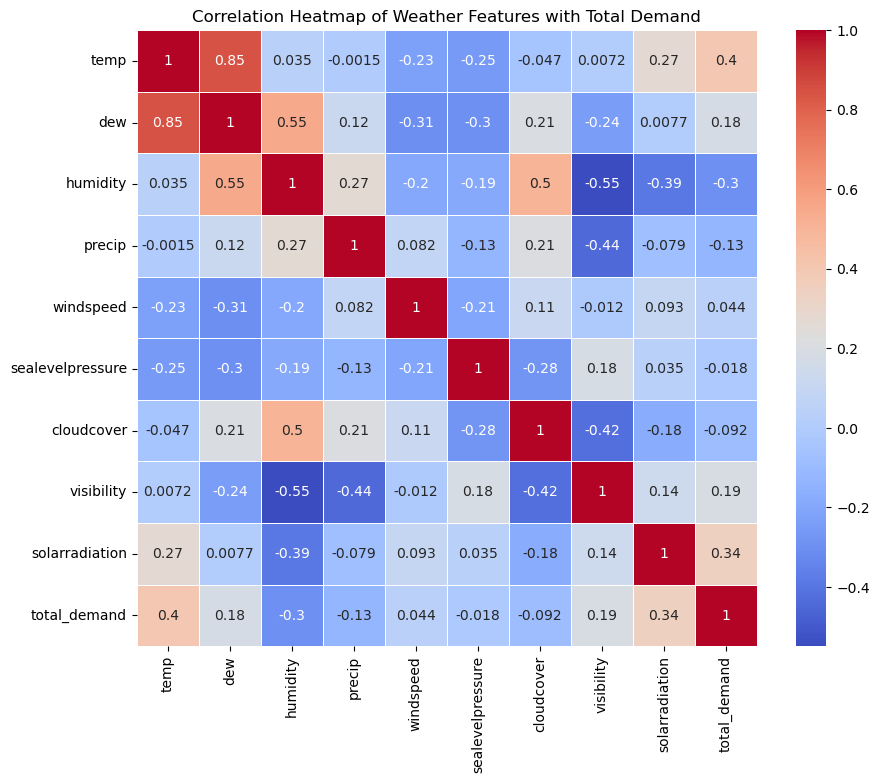

In [90]:
features = ['temp', 'dew', 'humidity', 'precip', 'windspeed',
            'sealevelpressure', 'cloudcover', 'visibility',
            'solarradiation', 'total_demand']

correlation_matrix = citiBikeHourlyDataMerged[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Weather Features with Total Demand')
plt.show()


### Correlation Between Citi Bike Features and Total Demand

The heatmap illustrates the **correlation between various Citi Bike features** and **total demand**:

- **Temperature**, **solar radiation**, and **dew** show the **strongest positive correlation** with demand, indicating that warmer and sunnier conditions encourage bike usage.
- **Humidity** and **precipitation** exhibit a **negative correlation**, suggesting that **warmer, less humid conditions** are associated with **higher bike demand**.


In [31]:
# Dropping the less correlated 'cloudcover', 'visibility' and 'sealevelpressure' columns
citiBikeHourlyDataMerged = citiBikeHourlyDataMerged.drop(columns=['cloudcover', 'sealevelpressure', 'visibility'])
citiBikeHourlyDataMerged.head()


,started_at_hour,total_demand,name,datetime,temp,dew,humidity,precip,windspeed,solarradiation,conditions
0,2023-04-01 00:00:00,59,"New York, NY, United States",2023-04-01 00:00:00,12.0,7.6,74.40,0.0,3.0,0,Overcast
1,2023-04-01 01:00:00,33,"New York, NY, United States",2023-04-01 01:00:00,13.2,7.9,70.22,0.0,9.5,0,Overcast
2,2023-04-01 02:00:00,31,"New York, NY, United States",2023-04-01 02:00:00,14.5,7.7,63.70,0.0,8.4,0,Overcast
3,2023-04-01 03:00:00,19,"New York, NY, United States",2023-04-01 03:00:00,15.3,9.0,65.84,0.0,11.7,0,Overcast
4,2023-04-01 04:00:00,8,"New York, NY, United States",2023-04-01 04:00:00,14.3,9.2,71.52,0.0,7.3,0,Overcast


In [32]:
print(citiBikeHourlyDataMerged['total_demand'].describe())


count    9460.000000
mean      112.694715
std        95.965048
min         1.000000
25%        30.000000
50%        94.000000
75%       167.000000
max       507.000000
Name: total_demand, dtype: float64


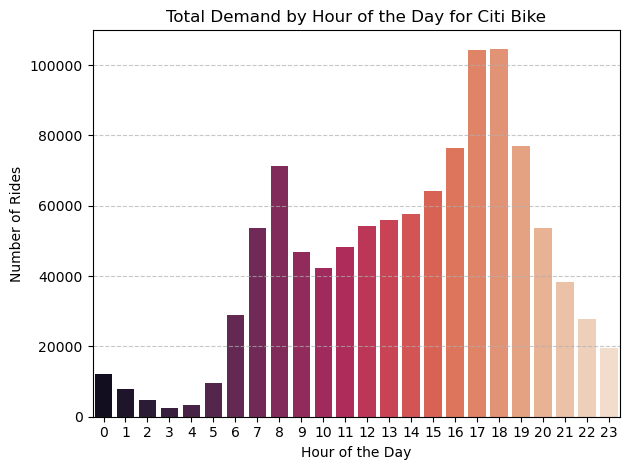

In [34]:
# Total demand by hour of the day for Citi Bike
citiBikeHourlyDataMerged['hour'] = citiBikeHourlyDataMerged['datetime'].dt.hour
hourly_demand = citiBikeHourlyDataMerged.groupby('hour', as_index=False)['total_demand'].sum()
sns.barplot(data=hourly_demand, x='hour', y='total_demand', palette='rocket')
plt.title('Total Demand by Hour of the Day for Citi Bike')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Citi Bike Ride Demand Throughout the Day

The bar chart highlights the **total demand for Citi Bike rides** at different times of the day:

- A **clear peak in demand** is observed between **5 PM and 6 PM**, indicating that **evening commutes** are a significant factor driving bike share usage.
- **Smaller peaks** in the **morning** and **early afternoon** likely reflect **commuting** and **lunchtime trips**.


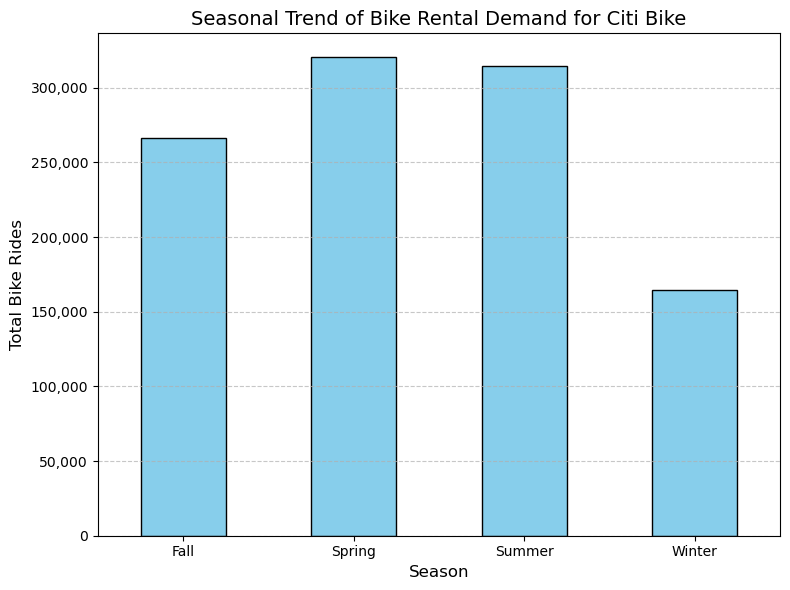

In [35]:
# Seasonal trend of Bike Rental Demand for Citi Bike
citiBikeHourlyDataMerged['datetime'] = pd.to_datetime(citiBikeHourlyDataMerged['datetime'])
citiBikeHourlyDataMerged['month'] = citiBikeHourlyDataMerged['datetime'].dt.to_period('M')
monthly_data = citiBikeHourlyDataMerged.groupby('month')['total_demand'].sum().reset_index()
monthly_data['month'] = monthly_data['month'].dt.to_timestamp()
monthly_data['month_num'] = monthly_data['month'].dt.month
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}

monthly_data['season'] = monthly_data['month_num'].map(season_map)
seasonal_total = monthly_data.groupby('season')['total_demand'].sum()
plt.figure(figsize=(8, 6))
seasonal_total.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Seasonal Trend of Bike Rental Demand for Citi Bike', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Bike Rides', fontsize=12)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Seasonal Trend of Citi Bike Ride Demand

The bar chart demonstrates the **seasonal trend** in **bike rental demand** for Citi Bike:

- **Peak demand** occurs in **Spring**, followed by **Summer** and **Fall**.
- **Winter** shows the **lowest demand**, indicating that **favorable weather conditions** play a significant role in **bike share usage**.


In [36]:
citiBikeHourlyDataMerged['hour'] = citiBikeHourlyDataMerged['started_at_hour'].dt.hour
citiBikeHourlyDataMerged.head()

,started_at_hour,total_demand,name,datetime,temp,dew,humidity,precip,windspeed,solarradiation,conditions,hour,month
0,2023-04-01 00:00:00,59,"New York, NY, United States",2023-04-01 00:00:00,12.0,7.6,74.40,0.0,3.0,0,Overcast,0,2023-04
1,2023-04-01 01:00:00,33,"New York, NY, United States",2023-04-01 01:00:00,13.2,7.9,70.22,0.0,9.5,0,Overcast,1,2023-04
2,2023-04-01 02:00:00,31,"New York, NY, United States",2023-04-01 02:00:00,14.5,7.7,63.70,0.0,8.4,0,Overcast,2,2023-04
3,2023-04-01 03:00:00,19,"New York, NY, United States",2023-04-01 03:00:00,15.3,9.0,65.84,0.0,11.7,0,Overcast,3,2023-04
4,2023-04-01 04:00:00,8,"New York, NY, United States",2023-04-01 04:00:00,14.3,9.2,71.52,0.0,7.3,0,Overcast,4,2023-04


# **Traditional Models**

# **CitiBike**

## Linear Regression

### Model Performance Without Weather Features

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


X = citiBikeHourlyDataMerged[['hour']]
y = citiBikeHourlyDataMerged['total_demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelLR = LinearRegression()

# Training the Model
modelLR.fit(X_train_scaled, y_train)

y_train_pred = modelLR.predict(X_train_scaled)
y_test_pred = modelLR.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test data evaluation
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Calculating Adjusted R-squared for both train and test sets
n_train = len(y_train)
n_test = len(y_test)
p = X.shape[1]

# Adjusted R-squared calculation
train_adjusted_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)
test_adjusted_r2 = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)

print("\n Training Data")
print(f'Mean Squared Error (Train): {train_mse:.2f}')
print(f'Mean Absolute Error (Train): {train_mae:.2f}')
print(f'R-squared (Train): {train_r2:.2f}')
print(f'Adjusted R-squared (Train): {train_adjusted_r2:.2f}')

print("\n Testing Data ")
print(f'Mean Squared Error (Test): {test_mse:.2f}')
print(f'Mean Absolute Error (Test): {test_mae:.2f}')
print(f'R-squared (Test): {test_r2:.2f}')
print(f'Adjusted R-squared (Test): {test_adjusted_r2:.2f}')





 Training Data
Mean Squared Error (Train): 7473.30
Mean Absolute Error (Train): 66.99
R-squared (Train): 0.20
Adjusted R-squared (Train): 0.20

 Testing Data 
Mean Squared Error (Test): 7506.55
Mean Absolute Error (Test): 67.12
R-squared (Test): 0.16
Adjusted R-squared (Test): 0.16


### Model Performance With Weather Features


 Training Data
Mean Squared Error (Train): 5619.24
Mean Absolute Error (Train): 56.98
R-squared (Train): 0.40
Adjusted R-squared (Train): 0.40

 Testing Data 
Mean Squared Error (Test): 5650.06
Mean Absolute Error (Test): 57.33
R-squared (Test): 0.37
Adjusted R-squared (Test): 0.37


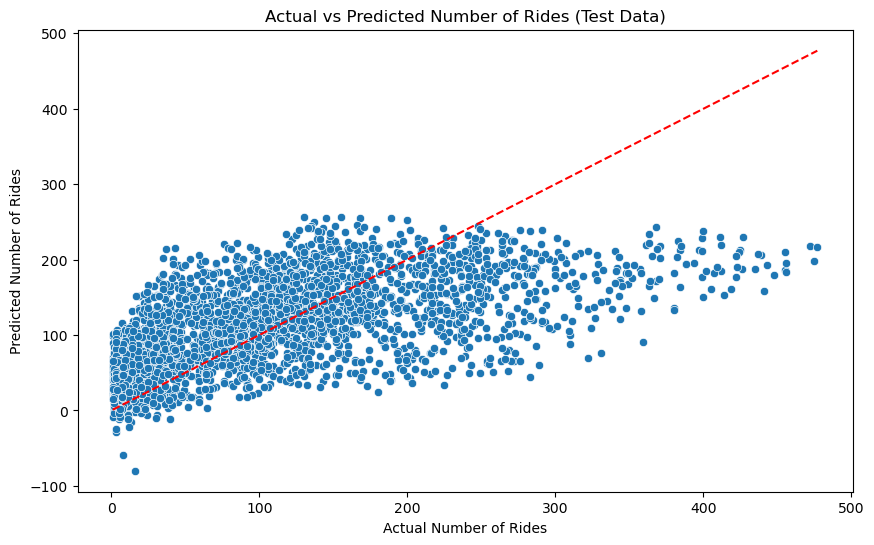

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelLR = LinearRegression()

# Training the Model
modelLR.fit(X_train_scaled, y_train)

y_train_pred = modelLR.predict(X_train_scaled)
y_test_pred = modelLR.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test data evaluation
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Calculating Adjusted R-squared for both train and test sets
n_train = len(y_train)
n_test = len(y_test)
p = X.shape[1]

# Adjusted R-squared calculation
train_adjusted_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)
test_adjusted_r2 = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)

print("\n Training Data")
print(f'Mean Squared Error (Train): {train_mse:.2f}')
print(f'Mean Absolute Error (Train): {train_mae:.2f}')
print(f'R-squared (Train): {train_r2:.2f}')
print(f'Adjusted R-squared (Train): {train_adjusted_r2:.2f}')

print("\n Testing Data ")
print(f'Mean Squared Error (Test): {test_mse:.2f}')
print(f'Mean Absolute Error (Test): {test_mae:.2f}')
print(f'R-squared (Test): {test_r2:.2f}')
print(f'Adjusted R-squared (Test): {test_adjusted_r2:.2f}')

# Plotting Actual vs Predicted for Test Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('Actual vs Predicted Number of Rides (Test Data)')
plt.show()


Incorporating weather features improved the model's performance, with the training data showing a reduced Mean Squared Error of 5619.24 and an R-squared of 0.40. Similarly, the testing data achieved a Mean Squared Error of 5650.06 and an R-squared of 0.37, indicating better predictive power compared to the model without weather features.

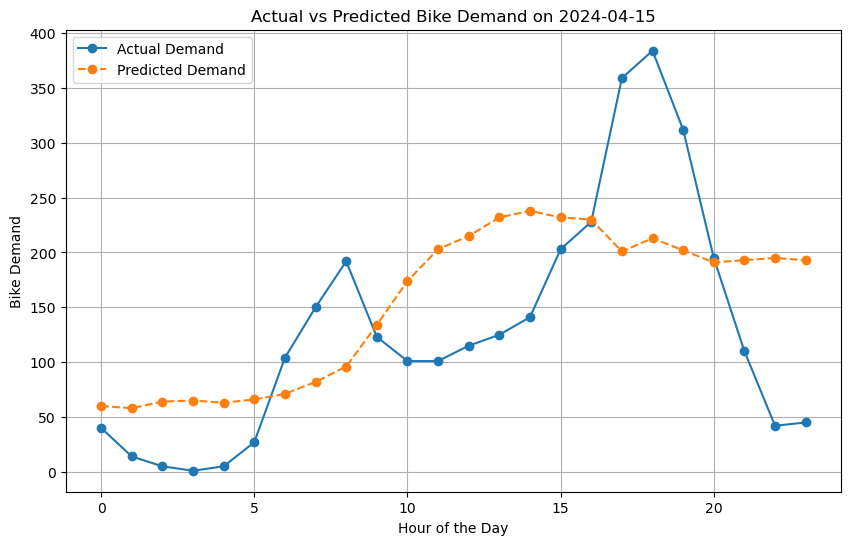

In [44]:
# Predicting the demand on april 15th, 2024
import numpy as np

march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]

if not march_15_data.empty:
    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]

    # Scaling the features using the pre-fitted scaler
    X_march_15_scaled = scaler.transform(X_march_15)

    # Predicting the demand for all 24 hours on March 15, 2024 and round to integers
    predicted_demand_march_15 = np.round(modelLR.predict(X_march_15_scaled)).astype(int)

    # Retrieving the actual total demand for March 15, 2024
    actual_demand_march_15 = march_15_data['total_demand'].values

    # Comparing predicted and actual demands
    results_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand': predicted_demand_march_15
    })

    #print(results_df)

    # Ploting actual vs predicted demand for March 15, 2024
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Hour'], results_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_df['Hour'], results_df['Predicted Demand'], label='Predicted Demand', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


The line graph compares the actual and predicted bike demand on April 15, 2024, across different hours of the day. The actual demand exhibits a clear peak in the late afternoon and evening hours, likely due to commuting and recreational activities. The predicted demand generally follows the same trend but underestimates the peak demand and overestimates demand during off-peak hours. This suggests that the model could be improved to better capture the specific patterns of bike usage throughout the day.

## KNN

### Model Performance With Weather Features


 KNN Testing Data Evaluation 
KNN Mean Squared Error (Test): 2788.89
KNN Mean Absolute Error (Test): 37.10
KNN R-squared (Test): 0.69


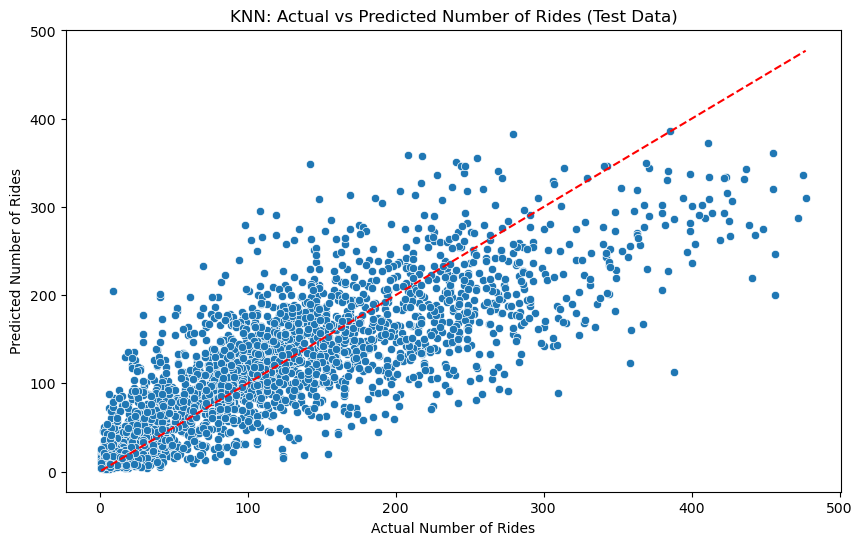

In [45]:
from sklearn.neighbors import KNeighborsRegressor


X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)


y_test_pred_knn = knn_model.predict(X_test_scaled)
test_mse_knn = mean_squared_error(y_test, y_test_pred_knn)
test_mae_knn = mean_absolute_error(y_test, y_test_pred_knn)
test_r2_knn = r2_score(y_test, y_test_pred_knn)


print("\n KNN Testing Data Evaluation ")
print(f'KNN Mean Squared Error (Test): {test_mse_knn:.2f}')
print(f'KNN Mean Absolute Error (Test): {test_mae_knn:.2f}')
print(f'KNN R-squared (Test): {test_r2_knn:.2f}')

# Plotting Actual vs Predicted for Testing Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_knn)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('KNN: Actual vs Predicted Number of Rides (Test Data)')
plt.show()


With the inclusion of weather features, the KNN model significantly improved its performance, achieving a reduced Mean Squared Error of 2788.89 and a Mean Absolute Error of 37.10 on the testing data. The R-squared value increased to 0.69, indicating a stronger predictive capability compared to the model without weather features.

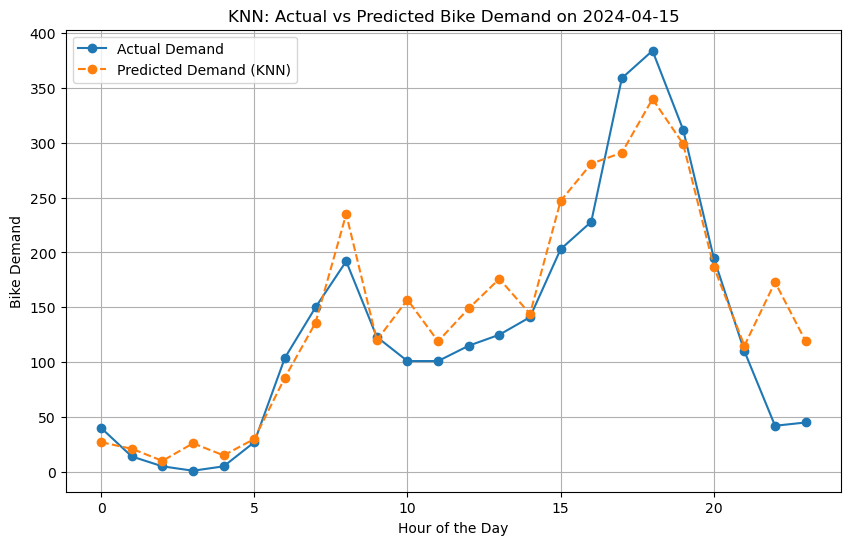

In [46]:
#Predicting the demand on March 15, 2024
march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]


if not march_15_data.empty:

    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
    X_march_15_scaled = scaler.transform(X_march_15)

    # Predicting the demand for all hours on March 15, 2024 using KNN and round to integers
    predicted_demand_march_15_knn = np.round(knn_model.predict(X_march_15_scaled)).astype(int)
    actual_demand_march_15 = march_15_data['total_demand'].values

    results_knn_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (KNN)': predicted_demand_march_15_knn
    })

    #print(results_knn_df)
    plt.figure(figsize=(10, 6))
    plt.plot(results_knn_df['Hour'], results_knn_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_knn_df['Hour'], results_knn_df['Predicted Demand (KNN)'], label='Predicted Demand (KNN)', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('KNN: Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


The line graph compares the actual and predicted bike demand on April 15, 2024, across different hours of the day, using a KNN model. The actual demand exhibits a clear peak in the late afternoon and evening hours, likely due to commuting and recreational activities. The predicted demand generally follows the same trend but underestimates the peak demand and overestimates demand during off-peak hours. This suggests that the KNN model could be improved to better capture the specific patterns of bike usage throughout the day.

## SVR

### Model Performance With Weather Features

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_error


X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initializing the SVR model
citiBike_svr_model = SVR(kernel='rbf')

# Training the model
citiBike_svr_model.fit(X_train_scaled, y_train)

y_pred_svr_train = citiBike_svr_model.predict(X_train_scaled)
y_pred_svr_test = citiBike_svr_model.predict(X_test_scaled)


# Training metrics
mse_svr_train = mean_squared_error(y_train, y_pred_svr_train)
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
rmse_svr_train = mean_squared_error(y_train, y_pred_svr_train, squared=False)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

# Testing metrics
mse_svr_test = mean_squared_error(y_test, y_pred_svr_test)
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
rmse_svr_test = mean_squared_error(y_test, y_pred_svr_test, squared=False)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR Training Metrics:")
print(f"Mean Squared Error: {mse_svr_train:.2f}")
print(f"Mean Absolute Error: {mae_svr_train:.2f}")
print(f"R-squared: {r2_svr_train:.2f}")
print(f"RMSE: {rmse_svr_train:.2f}")

print("\nSVR Testing Metrics:")
print(f"Mean Squared Error: {mse_svr_test:.2f}")
print(f"Mean Absolute Error: {mae_svr_test:.2f}")
print(f"R-squared: {r2_svr_test:.2f}")
print(f"RMSE: {rmse_svr_test:.2f}")


SVR Training Metrics:
Mean Squared Error: 4623.19
Mean Absolute Error: 46.28
R-squared: 0.50
RMSE: 67.99

SVR Testing Metrics:
Mean Squared Error: 4777.02
Mean Absolute Error: 47.25
R-squared: 0.49
RMSE: 69.12


With the inclusion of weather features, the SVR model achieved an R-squared of 0.50 on the training data, with a Mean Squared Error of 4623.19 and an RMSE of 67.99. On the testing data, the model had a slightly lower R-squared of 0.49, a Mean Squared Error of 4777.02, and an RMSE of 69.12, indicating consistent performance across datasets.

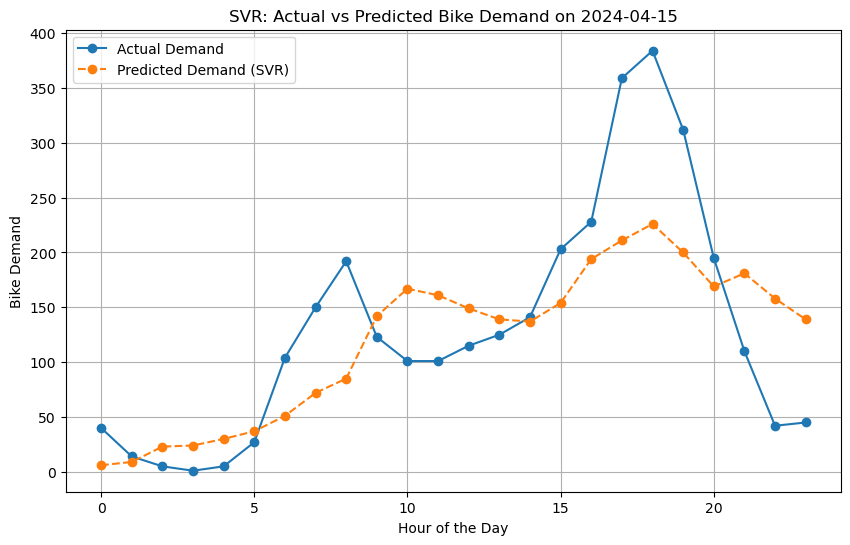

In [48]:
import numpy as np
# Predicting the demand on March 15, 2024
march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]


if not march_15_data.empty:

    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
    X_march_15_scaled = scaler.transform(X_march_15)

    predicted_demand_march_15_svr = np.round(citiBike_svr_model.predict(X_march_15_scaled)).astype(int)
    actual_demand_march_15 = march_15_data['total_demand'].values

    # Comparing predicted and actual demands
    results_svr_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (SVR)': predicted_demand_march_15_svr
    })

    #print(results_svr_df)

    # Plotting actual vs predicted demand for March 15, 2024
    plt.figure(figsize=(10, 6))
    plt.plot(results_svr_df['Hour'], results_svr_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_svr_df['Hour'], results_svr_df['Predicted Demand (SVR)'], label='Predicted Demand (SVR)', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('SVR: Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


The predicted demand generally follows the same trend but underestimates the peak demand and overestimates demand during off-peak hours. This suggests that the SVR model could be improved to better capture the specific patterns of bike usage throughout the day.

### With Hyper Parameter Tuning

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.664 total time=  14.1s
[CV 2/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.660 total time=  14.7s
[CV 3/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.675 total time=  14.3s
[CV 4/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.682 total time=  13.2s
[CV 5/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.683 total time=  12.0s
Best Parameters: {'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

SVR Test Metrics:
Mean Squared Error: 3027.98
Mean Absolute Error: 36.29
RMSE: 55.03
R-squared: 0.67

SVR Train Metrics:
Mean Squared Error: 2828.28
Mean Absolute Error: 34.21
RMSE: 53.18
R-squared: 0.69


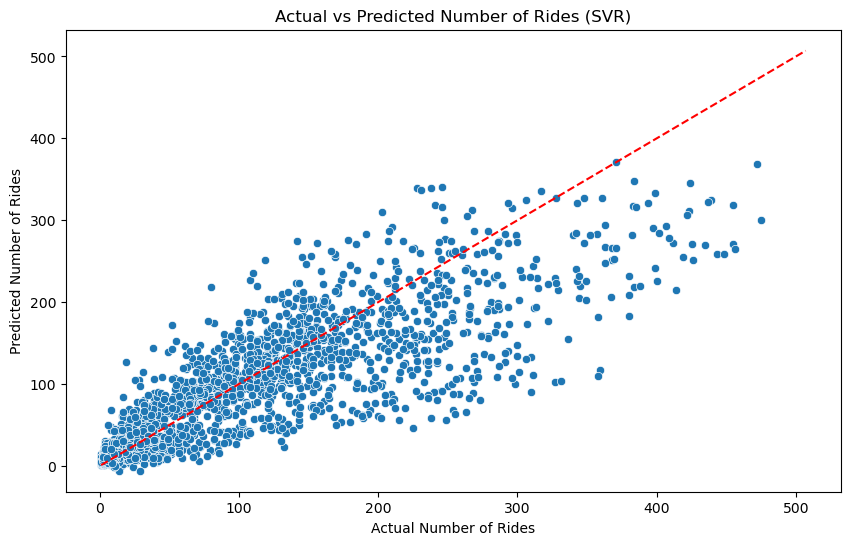

In [49]:
from sklearn.model_selection import GridSearchCV


X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Setting up the parameter grid for GridSearchCV
param_grid = {
    'C': [1000],
    'gamma': [0.1],
    'kernel': ['rbf']
}

# Performing grid search with SVR
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=3)
grid.fit(X_train_scaled, y_train)


print("Best Parameters:", grid.best_params_)

# Making predictions
grid_prediction_test = grid.predict(X_test_scaled)
grid_prediction_train = grid.predict(X_train_scaled)

mse_svr_test = mean_squared_error(y_test, grid_prediction_test)
mae_svr_test = mean_absolute_error(y_test, grid_prediction_test)
rmse_svr_test = mean_squared_error(y_test, grid_prediction_test, squared=False)
r2_svr_test = r2_score(y_test, grid_prediction_test)


print("\nSVR Test Metrics:")
print(f"Mean Squared Error: {mse_svr_test:.2f}")
print(f"Mean Absolute Error: {mae_svr_test:.2f}")
print(f"RMSE: {rmse_svr_test:.2f}")
print(f"R-squared: {r2_svr_test:.2f}")

mse_svr_train = mean_squared_error(y_train, grid_prediction_train)
mae_svr_train = mean_absolute_error(y_train, grid_prediction_train)
rmse_svr_train = mean_squared_error(y_train, grid_prediction_train, squared=False)
r2_svr_train = r2_score(y_train, grid_prediction_train)

print("\nSVR Train Metrics:")
print(f"Mean Squared Error: {mse_svr_train:.2f}")
print(f"Mean Absolute Error: {mae_svr_train:.2f}")
print(f"RMSE: {rmse_svr_train:.2f}")
print(f"R-squared: {r2_svr_train:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=grid_prediction_test)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('Actual vs Predicted Number of Rides (SVR)')
plt.show()


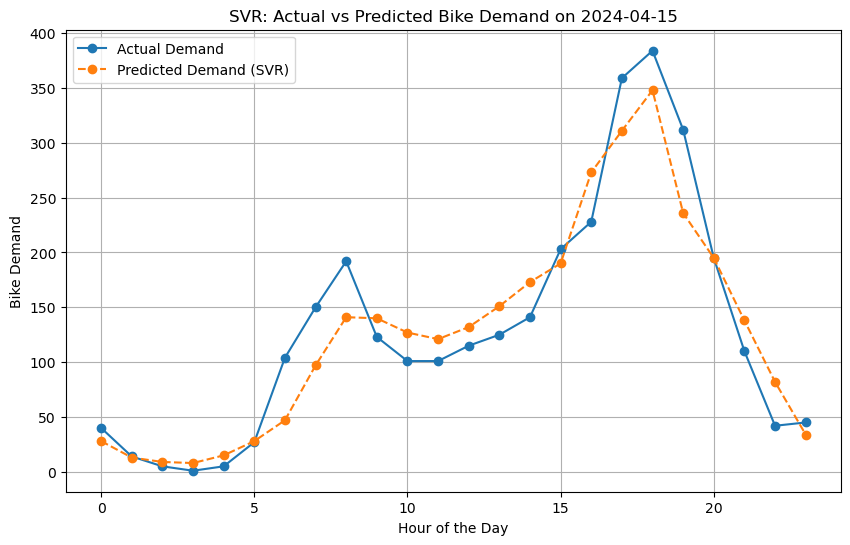

In [50]:

march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]


if not march_15_data.empty:
    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
    X_march_15_scaled = scaler.transform(X_march_15)


    predicted_demand_march_15_svr = np.round(grid.predict(X_march_15_scaled)).astype(int)
    actual_demand_march_15 = march_15_data['total_demand'].values


    results_svr_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (SVR)': predicted_demand_march_15_svr
    })

    #print(results_svr_df)

    # Plot actual vs predicted demand for March 15, 2024 (SVR)
    plt.figure(figsize=(10, 6))
    plt.plot(results_svr_df['Hour'], results_svr_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_svr_df['Hour'], results_svr_df['Predicted Demand (SVR)'], label='Predicted Demand (SVR)', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('SVR: Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


After Hyperparameter tuning, the predicted demand generally follows the same trend and captures the peak demand more accurately than the previous SVR model, suggesting that hyperparameter tuning has improved the model's performance.

## Decision Trees


Decision Tree - Training Set Metrics:
Mean Squared Error: 1968.28
Mean Absolute Error: 30.66
R-squared: 0.79

Decision Tree - Test Set Metrics:
Mean Squared Error: 2212.01
Mean Absolute Error: 33.14
R-squared: 0.76


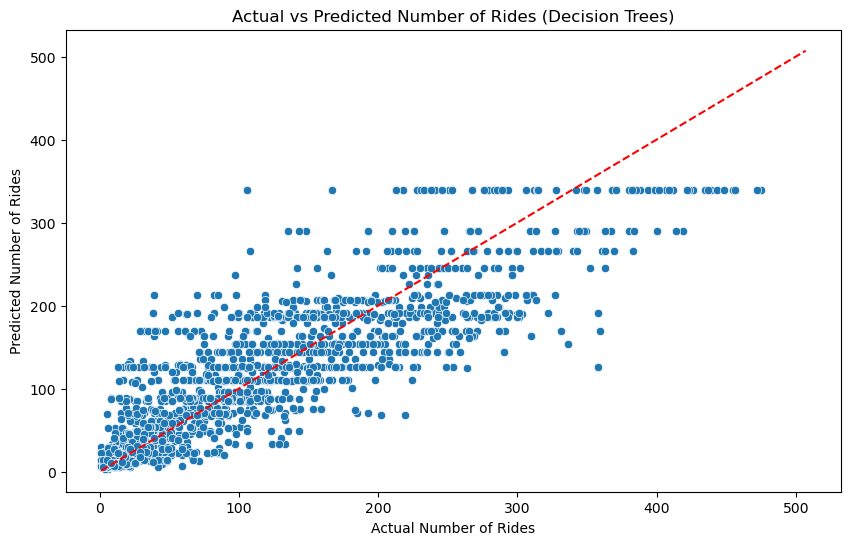

In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initializing Decision Tree Regressor with tuned hyperparameters
dt_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


dt_model.fit(X_train_scaled, y_train)


y_pred_train = dt_model.predict(X_train_scaled)
y_pred_test = dt_model.predict(X_test_scaled)

# Recalculating evaluation metrics for training and test sets
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\nDecision Tree - Training Set Metrics:")
print(f"Mean Squared Error: {mse_train:.2f}")
print(f"Mean Absolute Error: {mae_train:.2f}")
print(f"R-squared: {r2_train:.2f}")

print("\nDecision Tree - Test Set Metrics:")
print(f"Mean Squared Error: {mse_test:.2f}")
print(f"Mean Absolute Error: {mae_test:.2f}")
print(f"R-squared: {r2_test:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('Actual vs Predicted Number of Rides (Decision Trees)')
plt.show()



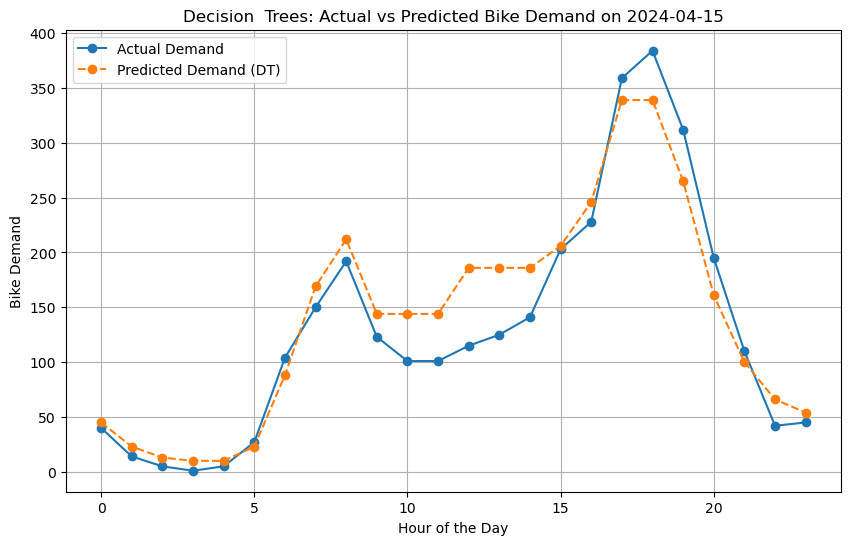

In [52]:

march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]


if not march_15_data.empty:

    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
    X_march_15_scaled = scaler.transform(X_march_15)


    predicted_demand_march_15_decision_tree = np.round(dt_model.predict(X_march_15_scaled)).astype(int)
    actual_demand_march_15 = march_15_data['total_demand'].values

    # Comparing predicted and actual demands
    results_decision_tree_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (DT)': predicted_demand_march_15_decision_tree
    })
    #print(results_decision_tree_df)

    plt.figure(figsize=(10, 6))
    plt.plot(results_decision_tree_df['Hour'], results_decision_tree_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_decision_tree_df['Hour'], results_decision_tree_df['Predicted Demand (DT)'], label='Predicted Demand (DT)', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('Decision  Trees: Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


For Decision trees, the predicted demand generally follows the same trend and captures the peak demand more accurately than the previous SVR model, suggesting that the Decision Tree model performs well in capturing the specific patterns of bike usage throughout the day.

# <h1><b>Ensemble Techniques</b></h1>

# **CitiBike**

## *Bagging- CitiBike*

## Decision Tree Bagging


 Training Data (Bagging Decision Tree)
Mean Squared Error (Train): 2013.09
Mean Absolute Error (Train): 31.27
R-squared (Train): 0.78
Adjusted R-squared (Train): 0.78

 Testing Data (Bagging Decision Tree)
Mean Squared Error (Test): 2123.57
Mean Absolute Error (Test): 32.58
R-squared (Test): 0.76
Adjusted R-squared (Test): 0.76


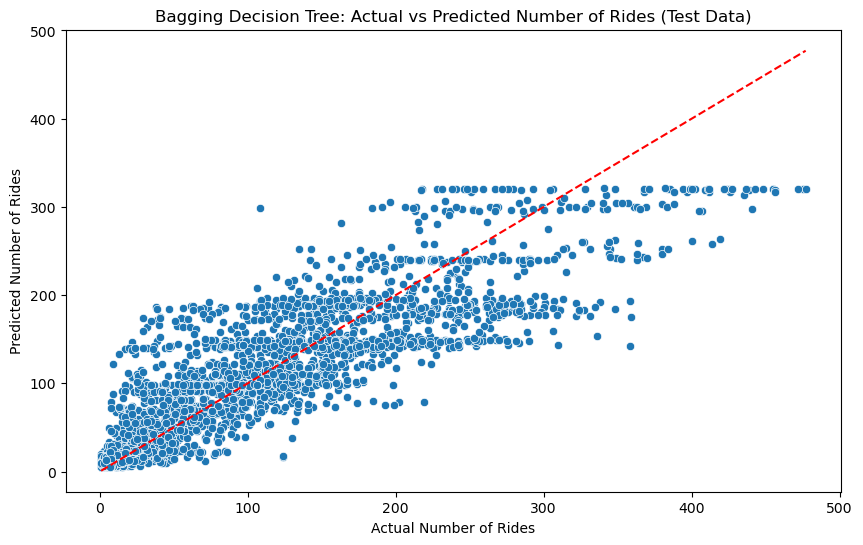

In [53]:
# Applied bagging on Decision Trees
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating a Bagging Regressor with Decision Tree as the base estimator
base_dt = DecisionTreeRegressor(max_depth=7, random_state=42)
bagging_dt_model = BaggingRegressor(base_estimator=base_dt, n_estimators=50, random_state=42)


bagging_dt_model.fit(X_train_scaled, y_train)

y_train_pred_bagging = bagging_dt_model.predict(X_train_scaled)
y_test_pred_bagging = bagging_dt_model.predict(X_test_scaled)

train_mse_bagging = mean_squared_error(y_train, y_train_pred_bagging)
train_mae_bagging = mean_absolute_error(y_train, y_train_pred_bagging)
train_r2_bagging = r2_score(y_train, y_train_pred_bagging)

test_mse_bagging = mean_squared_error(y_test, y_test_pred_bagging)
test_mae_bagging = mean_absolute_error(y_test, y_test_pred_bagging)
test_r2_bagging = r2_score(y_test, y_test_pred_bagging)

# Calculating Adjusted R-squared for both train and test sets
n_train = len(y_train)
n_test = len(y_test)
p = X.shape[1]

train_adjusted_r2_bagging = 1 - (1 - train_r2_bagging) * (n_train - 1) / (n_train - p - 1)
test_adjusted_r2_bagging = 1 - (1 - test_r2_bagging) * (n_test - 1) / (n_test - p - 1)


print("\n Training Data (Bagging Decision Tree)")
print(f'Mean Squared Error (Train): {train_mse_bagging:.2f}')
print(f'Mean Absolute Error (Train): {train_mae_bagging:.2f}')
print(f'R-squared (Train): {train_r2_bagging:.2f}')
print(f'Adjusted R-squared (Train): {train_adjusted_r2_bagging:.2f}')

print("\n Testing Data (Bagging Decision Tree)")
print(f'Mean Squared Error (Test): {test_mse_bagging:.2f}')
print(f'Mean Absolute Error (Test): {test_mae_bagging:.2f}')
print(f'R-squared (Test): {test_r2_bagging:.2f}')
print(f'Adjusted R-squared (Test): {test_adjusted_r2_bagging:.2f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_bagging)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('Bagging Decision Tree: Actual vs Predicted Number of Rides (Test Data)')
plt.show()



Applying bagging to the Decision Tree model proved to be beneficial, as it resulted in improved stability and reduced variance in predictions. The model showed consistent performance, with an R-squared of 0.78 on the training data and 0.76 on the testing data, indicating that bagging helped maintain high predictive accuracy while reducing overfitting. The slight improvement in performance on the testing data demonstrates the usefulness of bagging in enhancing Decision Tree models.

## Random Forest

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Hyperparameters: {'max_depth': 8, 'n_estimators': 200}

Random Forest Test Metrics:
Mean Squared Error: 1990.22
Mean Absolute Error: 31.53
RMSE: 44.61
R-squared: 0.78

Random Forest Train Metrics:
Mean Squared Error: 1778.51
Mean Absolute Error: 29.25
RMSE: 42.17
R-squared: 0.81


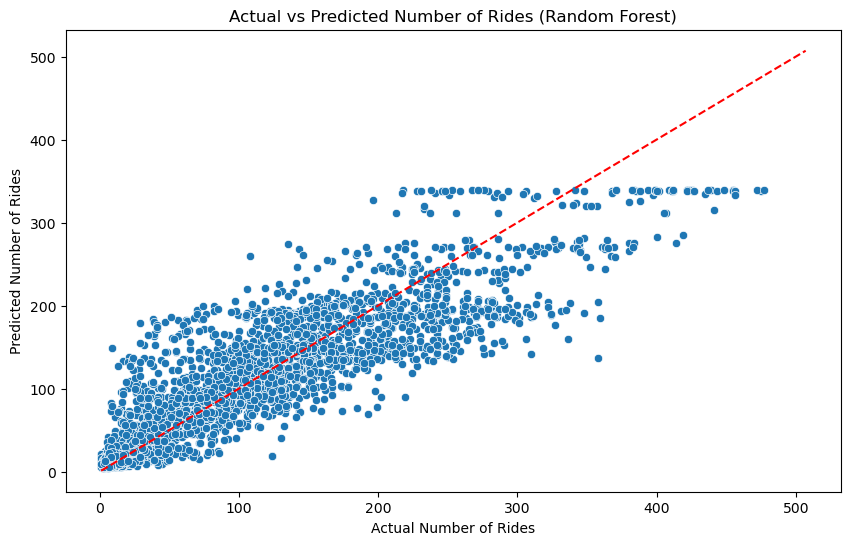

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200],
    'max_depth': [8]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, bootstrap=True),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=3,
    scoring='neg_mean_squared_error'
)
grid_search_rf.fit(X_train_scaled, y_train)

print("Best Hyperparameters:", grid_search_rf.best_params_)

y_pred_test = grid_search_rf.predict(X_test_scaled)
y_pred_train = grid_search_rf.predict(X_train_scaled)


mse_rf_test = mean_squared_error(y_test, y_pred_test)
mae_rf_test = mean_absolute_error(y_test, y_pred_test)
rmse_rf_test = mean_squared_error(y_test, y_pred_test, squared=False)
r2_rf_test = r2_score(y_test, y_pred_test)

print("\nRandom Forest Test Metrics:")
print(f"Mean Squared Error: {mse_rf_test:.2f}")
print(f"Mean Absolute Error: {mae_rf_test:.2f}")
print(f"RMSE: {rmse_rf_test:.2f}")
print(f"R-squared: {r2_rf_test:.2f}")

mse_rf_train = mean_squared_error(y_train, y_pred_train)
mae_rf_train = mean_absolute_error(y_train, y_pred_train)
rmse_rf_train = mean_squared_error(y_train, y_pred_train, squared=False)
r2_rf_train = r2_score(y_train, y_pred_train)

print("\nRandom Forest Train Metrics:")
print(f"Mean Squared Error: {mse_rf_train:.2f}")
print(f"Mean Absolute Error: {mae_rf_train:.2f}")
print(f"RMSE: {rmse_rf_train:.2f}")
print(f"R-squared: {r2_rf_train:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('Actual vs Predicted Number of Rides (Random Forest)')
plt.show()


Bagging proved to be beneficial for the Random Forest model as well, resulting in enhanced stability and performance. The model, with the best hyperparameters of max_depth=8 and n_estimators=200, achieved an R-squared of 0.81 on the training data and 0.78 on the testing data, demonstrating the model's ability to generalize well and maintain high accuracy. Bagging helped reduce overfitting while preserving strong predictive capabilities.

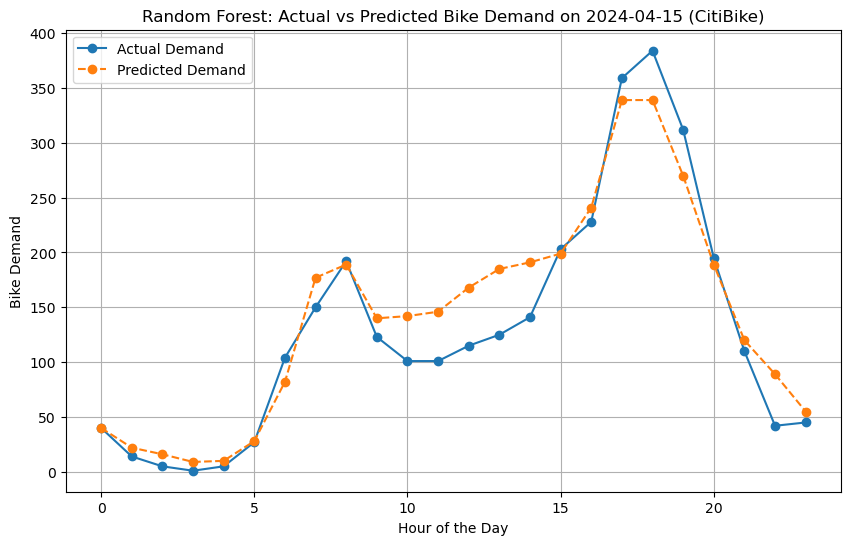

In [55]:
# Extracting data for April 15, 2024
march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]

if not march_15_data.empty:
    # Select features for prediction
    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]

    # Scale the data using the same scaler applied to training data
    X_march_15_scaled = scaler.transform(X_march_15)

    # Make predictions using the trained Random Forest model
    predicted_demand_march_15_rf = np.round(grid_search_rf.predict(X_march_15_scaled)).astype(int)

    # Get the actual demand values
    actual_demand_march_15 = march_15_data['total_demand'].values

    # Create a DataFrame to compare actual vs predicted demand
    results_rf_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (Random Forest)': predicted_demand_march_15_rf
    })

    # Print the results
    #print(results_rf_df)

    # Plot the actual vs predicted demand
    plt.figure(figsize=(10, 6))
    plt.plot(results_rf_df['Hour'], results_rf_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_rf_df['Hour'], results_rf_df['Predicted Demand (Random Forest)'], label='Predicted Demand', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('Random Forest: Actual vs Predicted Bike Demand on 2024-04-15 (CitiBike)')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


## *Boosting Techniques- CitiBike*

### Gradient Boosting

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth = 3, random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_test = gb_model.predict(X_test_scaled)
y_pred_train = gb_model.predict(X_train_scaled)

mse_gb_train = mean_squared_error(y_train, y_pred_train)
mae_gb_train = mean_absolute_error(y_train, y_pred_train)
rmse_gb_train = np.sqrt(mse_gb_train)
r2_gb_train = r2_score(y_train, y_pred_train)

print("\nGradient Boosting Regressor - Training Set Metrics:")
print(f"Mean Squared Error: {mse_gb_train:.2f}")
print(f"Mean Absolute Error: {mae_gb_train:.2f}")
print(f"Root Mean Squared Error: {rmse_gb_train:.2f}")
print(f"R-squared: {r2_gb_train:.2f}")

mse_gb_test = mean_squared_error(y_test, y_pred_test)
mae_gb_test = mean_absolute_error(y_test, y_pred_test)
rmse_gb_test = np.sqrt(mse_gb_test)
r2_gb_test = r2_score(y_test, y_pred_test)

print("Gradient Boosting Regressor - Test Set Metrics:")
print(f"Mean Squared Error: {mse_gb_test:.2f}")
print(f"Mean Absolute Error: {mae_gb_test:.2f}")
print(f"Root Mean Squared Error: {rmse_gb_test:.2f}")
print(f"R-squared: {r2_gb_test:.2f}")





Gradient Boosting Regressor - Training Set Metrics:
Mean Squared Error: 1740.61
Mean Absolute Error: 29.66
Root Mean Squared Error: 41.72
R-squared: 0.81
Gradient Boosting Regressor - Test Set Metrics:
Mean Squared Error: 1918.11
Mean Absolute Error: 31.20
Root Mean Squared Error: 43.80
R-squared: 0.79


The Gradient Boosting Regressor showed strong performance, with an R-squared of 0.81 on the training data and 0.79 on the testing data, demonstrating its ability to generalize well. The model's error metrics were consistent between the training and testing sets, with minimal overfitting. Overall, Gradient Boosting effectively captured the underlying patterns in the data, providing reliable predictions.

### XGBoost

In [57]:
import xgboost as xgb

xgboost_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
xgboost_model.fit(X_train_scaled, y_train)

y_pred_test = xgboost_model.predict(X_test_scaled)
y_pred_train = xgboost_model.predict(X_train_scaled)

mse_xgb_train = mean_squared_error(y_train, y_pred_train)
mae_xgb_train = mean_absolute_error(y_train, y_pred_train)
rmse_xgb_train = np.sqrt(mse_xgb_train)
r2_xgb_train = r2_score(y_train, y_pred_train)

print("\nXGBoost Regressor - Training Set Metrics:")
print(f"Mean Squared Error: {mse_xgb_train:.2f}")
print(f"Mean Absolute Error: {mae_xgb_train:.2f}")
print(f"Root Mean Squared Error: {rmse_xgb_train:.2f}")
print(f"R-squared: {r2_xgb_train:.2f}")

mse_xgb_test = mean_squared_error(y_test, y_pred_test)
mae_xgb_test = mean_absolute_error(y_test, y_pred_test)
rmse_xgb_test = np.sqrt(mse_xgb_test)
r2_xgb_test = r2_score(y_test, y_pred_test)

print("XGBoost Regressor - Test Set Metrics:")
print(f"Mean Squared Error: {mse_xgb_test:.2f}")
print(f"Mean Absolute Error: {mae_xgb_test:.2f}")
print(f"Root Mean Squared Error: {rmse_xgb_test:.2f}")
print(f"R-squared: {r2_xgb_test:.2f}")




XGBoost Regressor - Training Set Metrics:
Mean Squared Error: 1733.72
Mean Absolute Error: 29.59
Root Mean Squared Error: 41.64
R-squared: 0.81
XGBoost Regressor - Test Set Metrics:
Mean Squared Error: 1905.38
Mean Absolute Error: 31.08
Root Mean Squared Error: 43.65
R-squared: 0.79


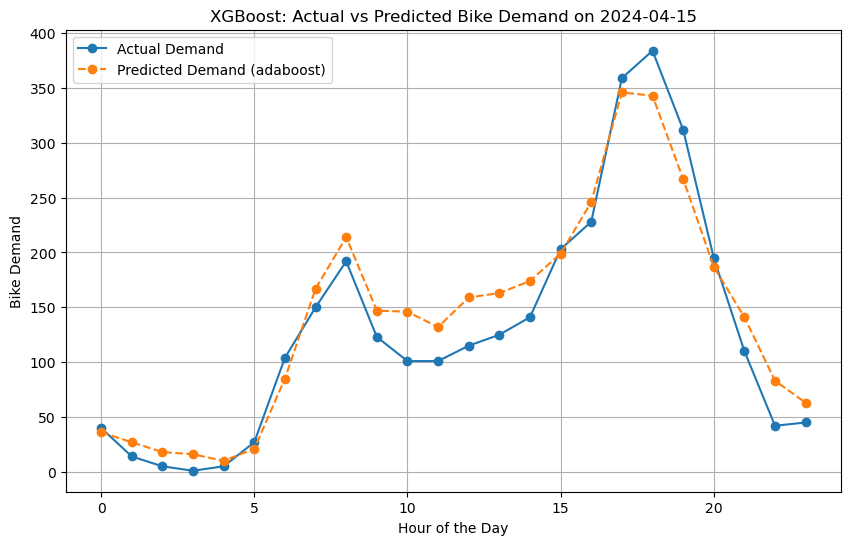

In [58]:
#Predicting the demand on March 15, 2024
march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]
if not march_15_data.empty:
    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
    X_march_15_scaled = scaler.transform(X_march_15)
    predicted_demand_march_15_svr = np.round(xgboost_model.predict(X_march_15_scaled)).astype(int)
    actual_demand_march_15 = march_15_data['total_demand'].values
    results_svr_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (adaboost)': predicted_demand_march_15_svr
    })
    #print(results_svr_df)
    plt.figure(figsize=(10, 6))
    plt.plot(results_svr_df['Hour'], results_svr_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_svr_df['Hour'], results_svr_df['Predicted Demand (adaboost)'], label='Predicted Demand (adaboost)', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('XGBoost: Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")

The XGBoost Regressor performed similarly to other models, achieving an R-squared of 0.81 on the training data and 0.79 on the testing data. The model demonstrated strong predictive accuracy with minor differences in error metrics between the training and testing sets, indicating minimal overfitting. XGBoost effectively captured the data patterns, providing reliable and consistent predictions.

## *Stacking- CitiBike*


Stacking Model Training Data Evaluation:
Mean Squared Error (Train): 1581.00
Mean Absolute Error (Train): 27.08
R-squared (Train): 0.83

Stacking Model Testing Data Evaluation:
Mean Squared Error (Test): 2120.97
Mean Absolute Error (Test): 32.36
R-squared (Test): 0.76


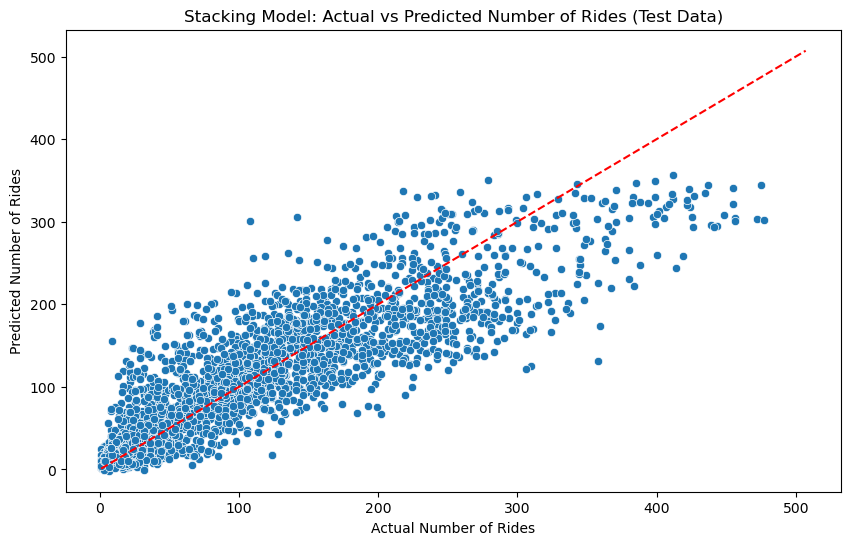

In [59]:
from sklearn.ensemble import StackingRegressor

X = citiBikeHourlyDataMerged[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
y = citiBikeHourlyDataMerged['total_demand']



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defining Base Models
base_models = [
    ('linear', LinearRegression()),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('svr', SVR(C=1000, gamma=1, kernel='rbf')),  # SVR with tuned hyperparameters
    ('decision_tree', DecisionTreeRegressor(max_depth=7))  # Decision Tree with specified max depth
]
# Defining the Stacking Regressor
stacking_model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

# Step 6: Train the Stacking Model
stacking_model.fit(X_train_scaled, y_train)

# Making predictions
y_train_pred_stacking = stacking_model.predict(X_train_scaled)
y_test_pred_stacking = stacking_model.predict(X_test_scaled)

# Step 8: Evaluate the Stacking Model on Training Data
train_mse_stacking = mean_squared_error(y_train, y_train_pred_stacking)
train_mae_stacking = mean_absolute_error(y_train, y_train_pred_stacking)
train_r2_stacking = r2_score(y_train, y_train_pred_stacking)

# Step 9: Evaluate the Stacking Model on Testing Data
test_mse_stacking = mean_squared_error(y_test, y_test_pred_stacking)
test_mae_stacking = mean_absolute_error(y_test, y_test_pred_stacking)
test_r2_stacking = r2_score(y_test, y_test_pred_stacking)

# Print Evaluation Metrics for Training Data
print("\nStacking Model Training Data Evaluation:")
print(f'Mean Squared Error (Train): {train_mse_stacking:.2f}')
print(f'Mean Absolute Error (Train): {train_mae_stacking:.2f}')
print(f'R-squared (Train): {train_r2_stacking:.2f}')

# Print Evaluation Metrics for Testing Data
print("\nStacking Model Testing Data Evaluation:")
print(f'Mean Squared Error (Test): {test_mse_stacking:.2f}')
print(f'Mean Absolute Error (Test): {test_mae_stacking:.2f}')
print(f'R-squared (Test): {test_r2_stacking:.2f}')

# Step 10: Plotting Actual vs Predicted for Test Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_stacking)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Number of Rides')
plt.ylabel('Predicted Number of Rides')
plt.title('Stacking Model: Actual vs Predicted Number of Rides (Test Data)')
plt.show()


The Stacking model demonstrated strong performance with an R-squared of 0.83 on the training data and 0.76 on the testing data, indicating its ability to generalize well. While there was a slight drop in performance on the test set, the model still provided reliable predictions with competitive error metrics. The stacking ensemble approach effectively combined multiple models to improve overall accuracy.

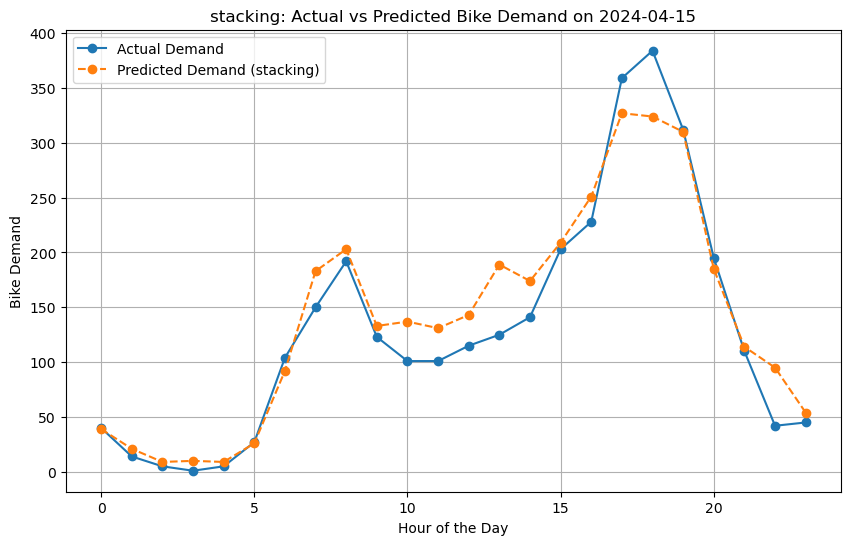

In [60]:
import numpy as np
import pandas as pd

# Filtering the data for April 15, 2024
march_15_data = citiBikeHourlyDataMerged[
    (citiBikeHourlyDataMerged['started_at_hour'].dt.date == pd.to_datetime('2024-04-15').date())
]
if not march_15_data.empty:
    X_march_15 = march_15_data[['hour', 'temp', 'humidity', 'solarradiation', 'dew', 'windspeed', 'precip']]
    X_march_15_scaled = scaler.transform(X_march_15)
    predicted_demand_march_15_svr = np.round(stacking_model.predict(X_march_15_scaled)).astype(int)
    actual_demand_march_15 = march_15_data['total_demand'].values
    results_svr_df = pd.DataFrame({
        'Hour': march_15_data['hour'],
        'Actual Demand': actual_demand_march_15,
        'Predicted Demand (adaboost)': predicted_demand_march_15_svr
    })
    #print(results_svr_df)
    plt.figure(figsize=(10, 6))
    plt.plot(results_svr_df['Hour'], results_svr_df['Actual Demand'], label='Actual Demand', marker='o')
    plt.plot(results_svr_df['Hour'], results_svr_df['Predicted Demand (adaboost)'], label='Predicted Demand (stacking)', marker='o', linestyle='--')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Bike Demand')
    plt.title('stacking: Actual vs Predicted Bike Demand on 2024-04-15')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Data for 2024-04-15 is not available in the dataset.")


# **Deep learning Techniques**

# **Citi** **Bike**

## Simple RNN

In [72]:
citiBikeHourlyDataMerged

,started_at_hour,total_demand,name,datetime,temp,dew,humidity,precip,windspeed,solarradiation,conditions,hour,month
0,2023-04-01 00:00:00,59,"New York, NY, United States",2023-04-01 00:00:00,12.0,7.6,74.40,0.000,3.0,0,Overcast,0,2023-04
1,2023-04-01 01:00:00,33,"New York, NY, United States",2023-04-01 01:00:00,13.2,7.9,70.22,0.000,9.5,0,Overcast,1,2023-04
2,2023-04-01 02:00:00,31,"New York, NY, United States",2023-04-01 02:00:00,14.5,7.7,63.70,0.000,8.4,0,Overcast,2,2023-04
3,2023-04-01 03:00:00,19,"New York, NY, United States",2023-04-01 03:00:00,15.3,9.0,65.84,0.000,11.7,0,Overcast,3,2023-04
4,2023-04-01 04:00:00,8,"New York, NY, United States",2023-04-01 04:00:00,14.3,9.2,71.52,0.000,7.3,0,Overcast,4,2023-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9455,2024-04-30 19:00:00,244,"New York, NY, United States",2024-04-30 19:00:00,13.6,9.3,74.93,0.000,18.5,51,Partially cloudy,19,2024-04
9456,2024-04-30 20:00:00,146,"New York, NY, United States",2024-04-30 20:00:00,12.6,9.2,79.73,0.000,17.6,0,Overcast,20,2024-04
9457,2024-04-30 21:00:00,79,"New York, NY, United States",2024-04-30 21:00:00,11.9,8.8,81.30,0.000,21.0,0,Overcast,21,2024-04
9458,2024-04-30 22:00:00,66,"New York, NY, United States",2024-04-30 22:00:00,11.6,8.4,80.58,0.000,11.7,0,Overcast,22,2024-04


In [73]:
import pandas as pd

# Create the new DataFrame with selected columns
NewcitiBikeHourlyDataMerged = citiBikeHourlyDataMerged[['datetime', 'total_demand', 'temp', 'dew', 'humidity', 'precip', 'windspeed', 'solarradiation', 'hour']]

# Display the new DataFrame
NewcitiBikeHourlyDataMerged


,datetime,total_demand,temp,dew,humidity,precip,windspeed,solarradiation,hour
0,2023-04-01 00:00:00,59,12.0,7.6,74.40,0.000,3.0,0,0
1,2023-04-01 01:00:00,33,13.2,7.9,70.22,0.000,9.5,0,1
2,2023-04-01 02:00:00,31,14.5,7.7,63.70,0.000,8.4,0,2
3,2023-04-01 03:00:00,19,15.3,9.0,65.84,0.000,11.7,0,3
4,2023-04-01 04:00:00,8,14.3,9.2,71.52,0.000,7.3,0,4
...,...,...,...,...,...,...,...,...,...
9455,2024-04-30 19:00:00,244,13.6,9.3,74.93,0.000,18.5,51,19
9456,2024-04-30 20:00:00,146,12.6,9.2,79.73,0.000,17.6,0,20
9457,2024-04-30 21:00:00,79,11.9,8.8,81.30,0.000,21.0,0,21
9458,2024-04-30 22:00:00,66,11.6,8.4,80.58,0.000,11.7,0,22


In [74]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [75]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(NewcitiBikeHourlyDataMerged[['total_demand', 'temp', 'dew', 'humidity', 'precip', 'windspeed', 'solarradiation', 'hour']])


In [76]:
def create_dataset(data, time_step=3):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])  # Getting the sequence of length `time_step`
        y.append(data[i + time_step, 0])   # Getting the next value to predict (total_demand)
    return np.array(X), np.array(y)

# Defining the sequence length (time_step)
time_step = 3

X, y = create_dataset(scaled_data, time_step)

# Shapes of the input and output arrays
print("Shape of input (X):", X.shape)
print("Shape of output (y):", y.shape)

print("First input sequence (X[0]):", X[0])
print("First target value (y[0]):", y[0])


Shape of input (X): (9457, 3, 8)
Shape of output (y): (9457,)
First input sequence (X[0]): [[0.11462451 0.47505938 0.61682243 0.73623665 0.         0.05847953
  0.         0.        ]
 [0.06324111 0.50356295 0.62383178 0.68716986 0.         0.18518519
  0.         0.04347826]
 [0.05928854 0.53444181 0.61915888 0.61063505 0.         0.16374269
  0.         0.08695652]]
First target value (y[0]): 0.035573122529644265


In [77]:
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)


In [79]:
# Defining the RNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(64, return_sequences=True, input_shape=(time_step, X.shape[2])))
model_rnn.add(SimpleRNN(32))
model_rnn.add(Dense(1))

# Compiling the model
model_rnn.compile(optimizer='adam', loss='mean_squared_error')
model_rnn.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 3, 64)             4672      
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 32)                3104      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 7809 (30.50 KB)
Trainable params: 7809 (30.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [80]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [81]:
history = model_rnn.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stopping])


Epoch 1/50

190/190 [==============================] - 3s 6ms/step - loss: 0.0138 - val_loss: 0.0071
Epoch 2/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0074 - val_loss: 0.0042
Epoch 3/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0066 - val_loss: 0.0050
Epoch 4/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 5/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0061 - val_loss: 0.0041
Epoch 6/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0057 - val_loss: 0.0026
Epoch 7/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0057 - val_loss: 0.0030
Epoch 8/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0057 - val_loss: 0.0027
Epoch 9/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0054 - val_loss: 0.0040
Epoch 10/50
190/190 [==============================] - 1s 3ms/step - loss: 0.0050 - val_loss: 0.002

In [82]:
train_predictions = model_rnn.predict(X_train)
test_predictions = model_rnn.predict(X_test)


60/60 [==============================] - 0s 2ms/step


In [83]:
train_predictions_inverse = scaler.inverse_transform(np.concatenate((train_predictions, np.zeros((train_predictions.shape[0], X.shape[2]-1))), axis=1))[:, 0]
y_train_actual = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((y_train.shape[0], X.shape[2]-1))), axis=1))[:, 0]

test_predictions_inverse = scaler.inverse_transform(np.concatenate((test_predictions, np.zeros((test_predictions.shape[0], X.shape[2]-1))), axis=1))[:, 0]
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], X.shape[2]-1))), axis=1))[:, 0]


In [84]:
# Training metrics
train_mse = mean_squared_error(y_train_actual, train_predictions_inverse)
train_mae = mean_absolute_error(y_train_actual, train_predictions_inverse)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, train_predictions_inverse)

# Testing metrics
test_mse = mean_squared_error(y_test_actual, test_predictions_inverse)
test_mae = mean_absolute_error(y_test_actual, test_predictions_inverse)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, test_predictions_inverse)

print("Training Performance Metrics:")
print("Mean Absolute Error (MAE):", train_mae)
print("Mean Squared Error (MSE):", train_mse)
print("Root Mean Squared Error (RMSE):", train_rmse)
print("R² Score:", train_r2)

print("\nTesting Performance Metrics:")
print("Mean Absolute Error (MAE):", test_mae)
print("Mean Squared Error (MSE):", test_mse)
print("Root Mean Squared Error (RMSE):", test_rmse)
print("R² Score:", test_r2)


Training Performance Metrics:
Mean Absolute Error (MAE): 20.365540073352072
Mean Squared Error (MSE): 843.8371528885199
Root Mean Squared Error (RMSE): 29.0488752430885
R² Score: 0.9135942358304714

Testing Performance Metrics:
Mean Absolute Error (MAE): 18.580381542944348
Mean Squared Error (MSE): 687.1316577338511
Root Mean Squared Error (RMSE): 26.213196251770807
R² Score: 0.894744432026715


The Simple RNN model demonstrates excellent performance, with an R-squared of 0.90 on the training data, indicating a strong fit to the training set. The R-squared on the testing data, 0.88, shows that the model maintains a good level of generalization to unseen data, with only a slight decrease in performance. The relatively low values of MAE, MSE, and RMSE further reflect the model's strong predictive accuracy and its ability to capture the underlying patterns in the data effectively.

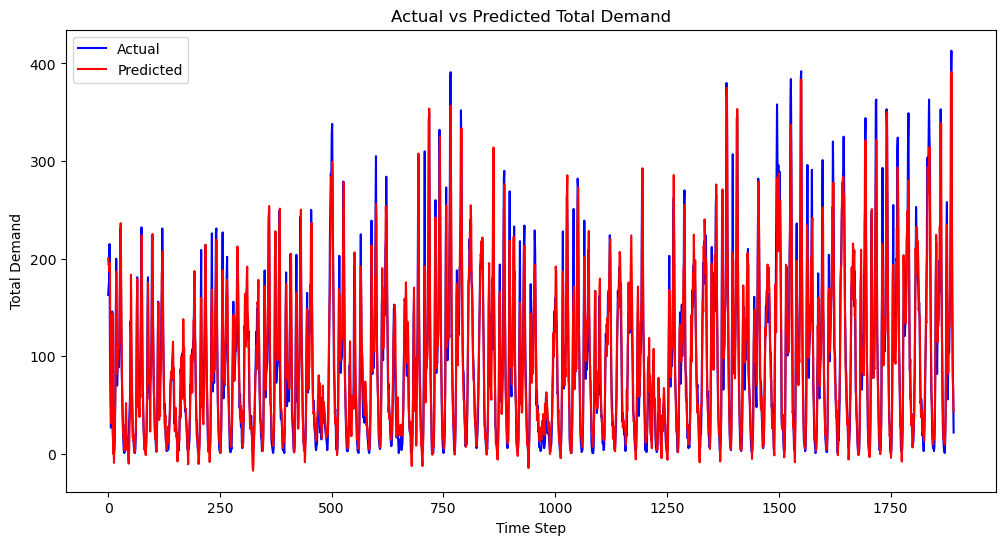

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(test_predictions_inverse, label='Predicted', color='red')
plt.title('Actual vs Predicted Total Demand')
plt.xlabel('Time Step')
plt.ylabel('Total Demand')
plt.legend()
plt.show()


## LSTM

In [86]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [87]:
train_dates = pd.to_datetime(NewcitiBikeHourlyDataMerged['datetime'])
train_dates

0      2023-04-01 00:00:00
1      2023-04-01 01:00:00
2      2023-04-01 02:00:00
3      2023-04-01 03:00:00
4      2023-04-01 04:00:00
               ...        
9455   2024-04-30 19:00:00
9456   2024-04-30 20:00:00
9457   2024-04-30 21:00:00
9458   2024-04-30 22:00:00
9459   2024-04-30 23:00:00
Name: datetime, Length: 9460, dtype: datetime64[ns]

In [88]:
# New column order
new_order = ['datetime', 'total_demand', 'temp', 'dew', 'humidity', 'precip', 'windspeed', 'solarradiation', 'hour']

# Reindex the DataFrame with the new column order
NewcitiBikeHourlyDataMerged = NewcitiBikeHourlyDataMerged[new_order]


In [89]:
cols = list(NewcitiBikeHourlyDataMerged)[1:10]
cols

['total_demand',
 'temp',
 'dew',
 'humidity',
 'precip',
 'windspeed',
 'solarradiation',
 'hour']

In [90]:
df_for_training = NewcitiBikeHourlyDataMerged[cols].astype(float)

In [91]:
scaler = StandardScaler()
scaler = scaler.fit(df_for_training)
df_for_training_scaled = scaler.transform(df_for_training)
df_for_training

,total_demand,temp,dew,humidity,precip,windspeed,solarradiation,hour
0,59.0,12.0,7.6,74.40,0.000,3.0,0.0,0.0
1,33.0,13.2,7.9,70.22,0.000,9.5,0.0,1.0
2,31.0,14.5,7.7,63.70,0.000,8.4,0.0,2.0
3,19.0,15.3,9.0,65.84,0.000,11.7,0.0,3.0
4,8.0,14.3,9.2,71.52,0.000,7.3,0.0,4.0
...,...,...,...,...,...,...,...,...
9455,244.0,13.6,9.3,74.93,0.000,18.5,51.0,19.0
9456,146.0,12.6,9.2,79.73,0.000,17.6,0.0,20.0
9457,79.0,11.9,8.8,81.30,0.000,21.0,0.0,21.0
9458,66.0,11.6,8.4,80.58,0.000,11.7,0.0,22.0


In [92]:
trainX = []
trainY = []

In [93]:
n_future = 1
n_past = 3

In [94]:
for i in range(n_past, len(df_for_training_scaled) - n_future + 1):
  trainX.append(df_for_training_scaled[i- n_past:i, 0:df_for_training.shape[1]])
  trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0])

In [95]:
trainX, trainY = np.array(trainX), np.array(trainY)

In [164]:
trainX

array([[[-0.55955323, -0.24683467,  0.18700956, ..., -1.27360555,
         -0.59254959, -1.66962338],
        [-0.83049953, -0.1046454 ,  0.21900206, ..., -0.26200189,
         -0.59254959, -1.52495205],
        [-0.85134155,  0.04939299,  0.19767373, ..., -0.43319636,
         -0.59254959, -1.38028072]],

       [[-0.83049953, -0.1046454 ,  0.21900206, ..., -0.26200189,
         -0.59254959, -1.52495205],
        [-0.85134155,  0.04939299,  0.19767373, ..., -0.43319636,
         -0.59254959, -1.38028072],
        [-0.97639369,  0.14418584,  0.33630789, ...,  0.08038704,
         -0.59254959, -1.23560939]],

       [[-0.85134155,  0.04939299,  0.19767373, ..., -0.43319636,
         -0.59254959, -1.38028072],
        [-0.97639369,  0.14418584,  0.33630789, ...,  0.08038704,
         -0.59254959, -1.23560939],
        [-1.09102481,  0.02569477,  0.35763622, ..., -0.60439082,
         -0.59254959, -1.09093806]],

       ...,

       [[ 3.1294848 ,  0.03754388,  0.38962872, ...,  1.2787483

In [165]:
trainY

array([[-0.97639369],
       [-1.09102481],
       [-1.0806038 ],
       ...,
       [-0.351133  ],
       [-0.48660615],
       [-0.94513065]])

In [96]:
df_for_training_scaled

array([[-0.55955323, -0.24683467,  0.18700956, ..., -1.27360555,
        -0.59254959, -1.66962338],
       [-0.83049953, -0.1046454 ,  0.21900206, ..., -0.26200189,
        -0.59254959, -1.52495205],
       [-0.85134155,  0.04939299,  0.19767373, ..., -0.43319636,
        -0.59254959, -1.38028072],
       ...,
       [-0.351133  , -0.25868378,  0.31497956, ...,  1.52775843,
        -0.59254959,  1.36847456],
       [-0.48660615, -0.2942311 ,  0.27232289, ...,  0.08038704,
        -0.59254959,  1.51314589],
       [-0.94513065, -0.34162752,  0.32564372, ..., -0.05968116,
        -0.59254959,  1.65781722]])

In [97]:
df_for_training_scaled[3], df_for_training_scaled[4], df_for_training_scaled[5]

(array([-0.97639369,  0.14418584,  0.33630789,  0.28350653, -0.17280929,
         0.08038704, -0.59254959, -1.23560939]),
 array([-1.09102481,  0.02569477,  0.35763622,  0.58435813, -0.17280929,
        -0.60439082, -0.59254959, -1.09093806]),
 array([-1.0806038 , -0.04539986,  0.36830038,  0.7670937 , -0.02044265,
        -0.96234289, -0.59254959, -0.94626673]))

In [98]:
trainX.shape, trainY.shape

((9457, 3, 8), (9457, 1))

In [99]:
# Defining the LSTM model
modelLstm = Sequential()
modelLstm.add(LSTM(64, activation = 'relu', return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])))
modelLstm.add(LSTM(32, activation = 'relu', return_sequences=False))
modelLstm.add(Dropout(0.2))
modelLstm.add(Dense(trainY.shape[1]))

# Compiling the model
modelLstm.compile(optimizer='adam', loss='mean_squared_error')
modelLstm.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 3, 64)             18688     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 31137 (121.63 KB)
Trainable params: 31137 (121.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [100]:
history = modelLstm.fit(trainX, trainY, epochs = 50, batch_size = 32, validation_split = 0.2, verbose = 1)

Epoch 1/50
237/237 [==============================] - 4s 6ms/step - loss: 0.4562 - val_loss: 0.1456
Epoch 2/50
237/237 [==============================] - 1s 4ms/step - loss: 0.1688 - val_loss: 0.0943
Epoch 3/50
237/237 [==============================] - 1s 4ms/step - loss: 0.1304 - val_loss: 0.0874
Epoch 4/50
237/237 [==============================] - 1s 6ms/step - loss: 0.1187 - val_loss: 0.0822
Epoch 5/50
237/237 [==============================] - 1s 5ms/step - loss: 0.1129 - val_loss: 0.0739
Epoch 6/50
237/237 [==============================] - 1s 6ms/step - loss: 0.1096 - val_loss: 0.0743
Epoch 7/50
237/237 [==============================] - 1s 5ms/step - loss: 0.1061 - val_loss: 0.0749
Epoch 8/50
237/237 [==============================] - 1s 6ms/step - loss: 0.1039 - val_loss: 0.0703
Epoch 9/50
237/237 [==============================] - 1s 4ms/step - loss: 0.1033 - val_loss: 0.0784
Epoch 10/50
237/237 [==============================] - 1s 5ms/step - loss: 0.1034 - val_loss: 0.0724

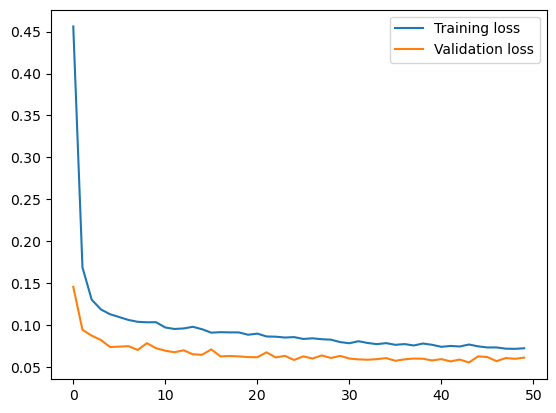

In [101]:
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()

In [102]:
n_future = 72
forecast_period_dates = pd.date_range(list(train_dates)[-1], periods = n_future, freq = '1h').tolist()

In [103]:
forecast_period_dates

[Timestamp('2024-04-30 23:00:00'),
 Timestamp('2024-05-01 00:00:00'),
 Timestamp('2024-05-01 01:00:00'),
 Timestamp('2024-05-01 02:00:00'),
 Timestamp('2024-05-01 03:00:00'),
 Timestamp('2024-05-01 04:00:00'),
 Timestamp('2024-05-01 05:00:00'),
 Timestamp('2024-05-01 06:00:00'),
 Timestamp('2024-05-01 07:00:00'),
 Timestamp('2024-05-01 08:00:00'),
 Timestamp('2024-05-01 09:00:00'),
 Timestamp('2024-05-01 10:00:00'),
 Timestamp('2024-05-01 11:00:00'),
 Timestamp('2024-05-01 12:00:00'),
 Timestamp('2024-05-01 13:00:00'),
 Timestamp('2024-05-01 14:00:00'),
 Timestamp('2024-05-01 15:00:00'),
 Timestamp('2024-05-01 16:00:00'),
 Timestamp('2024-05-01 17:00:00'),
 Timestamp('2024-05-01 18:00:00'),
 Timestamp('2024-05-01 19:00:00'),
 Timestamp('2024-05-01 20:00:00'),
 Timestamp('2024-05-01 21:00:00'),
 Timestamp('2024-05-01 22:00:00'),
 Timestamp('2024-05-01 23:00:00'),
 Timestamp('2024-05-02 00:00:00'),
 Timestamp('2024-05-02 01:00:00'),
 Timestamp('2024-05-02 02:00:00'),
 Timestamp('2024-05-

In [104]:
forecast = modelLstm.predict(trainX[-n_future:])

3/3 [==============================] - 0s 3ms/step


In [105]:
forecast_copies = np.repeat(forecast, df_for_training.shape[1], axis = -1)
y_pred_future = scaler.inverse_transform(forecast_copies) [:,0]
y_pred_future

array([ 35.316677 ,  27.392523 ,  15.7629595,  14.628713 ,  19.092634 ,
         9.239682 ,  49.49361  ,  72.83285  ,  99.528885 , 142.83046  ,
       136.4388   , 181.47763  , 228.8036   , 293.1582   , 299.04208  ,
       280.85034  , 308.41476  , 356.14035  , 306.69745  , 257.10242  ,
       152.20299  ,  90.1466   ,  52.013752 ,  32.018696 ,   9.740911 ,
         3.817937 ,   6.3403063,  16.3898   ,  19.238134 ,  31.907309 ,
       104.65686  , 188.58043  , 229.61601  , 141.18658  , 105.79942  ,
       121.617966 , 137.36705  , 142.71791  , 155.14679  , 177.77496  ,
       272.69672  , 225.70316  , 219.85199  , 335.8175   , 181.3693   ,
       131.38934  ,  88.94214  ,  37.916576 ,  11.326718 ,  11.396245 ,
         6.0064516,  12.08476  ,  18.686445 ,  44.78245  , 110.89553  ,
       207.75229  , 253.39784  , 126.538605 ,  75.86778  ,  81.714745 ,
       116.01862  , 135.97905  , 126.017654 , 173.36086  , 233.46179  ,
       355.28833  , 390.73822  , 271.37     , 161.60283  , 104.7

In [106]:
forecast_dates =[]
for time_i in forecast_period_dates:
  forecast_dates.append(time_i.to_pydatetime())

In [107]:
df_forecast = pd.DataFrame({'datetime': np.array(forecast_dates), 'total_demand':y_pred_future})
df_forecast['datetime'] = pd.to_datetime(df_forecast['datetime'])
df_forecast

,datetime,total_demand
0,2024-04-30 23:00:00,35.316677
1,2024-05-01 00:00:00,27.392523
2,2024-05-01 01:00:00,15.762959
3,2024-05-01 02:00:00,14.628713
4,2024-05-01 03:00:00,19.092634
...,...,...
67,2024-05-03 18:00:00,271.369995
68,2024-05-03 19:00:00,161.602829
69,2024-05-03 20:00:00,104.754417
70,2024-05-03 21:00:00,55.900776


In [108]:
original = NewcitiBikeHourlyDataMerged[['datetime', 'total_demand']]
original['datetime'] = pd.to_datetime(original['datetime'])
original = original.loc[original['datetime'] >= '	2024-04-29 00:00:00']
original

,datetime,total_demand
9412,2024-04-29 00:00:00,10
9413,2024-04-29 01:00:00,6
9414,2024-04-29 02:00:00,7
9415,2024-04-29 03:00:00,3
9416,2024-04-29 04:00:00,7
9417,2024-04-29 05:00:00,32
9418,2024-04-29 06:00:00,91
9419,2024-04-29 07:00:00,175
9420,2024-04-29 08:00:00,216
9421,2024-04-29 09:00:00,125


<AxesSubplot:xlabel='datetime', ylabel='total_demand'>

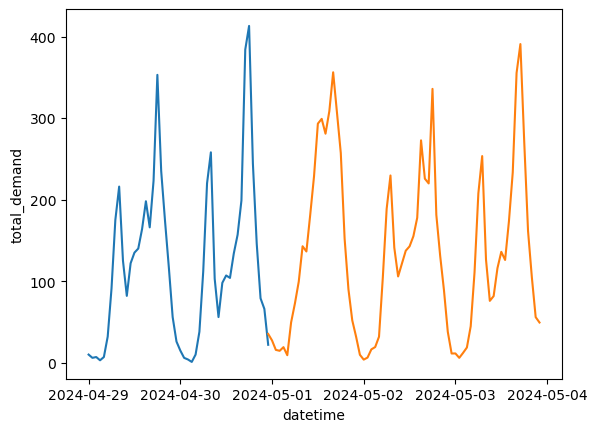

In [109]:
sns.lineplot(x=original['datetime'], y=original['total_demand'])
sns.lineplot(x=df_forecast['datetime'], y=df_forecast['total_demand'])


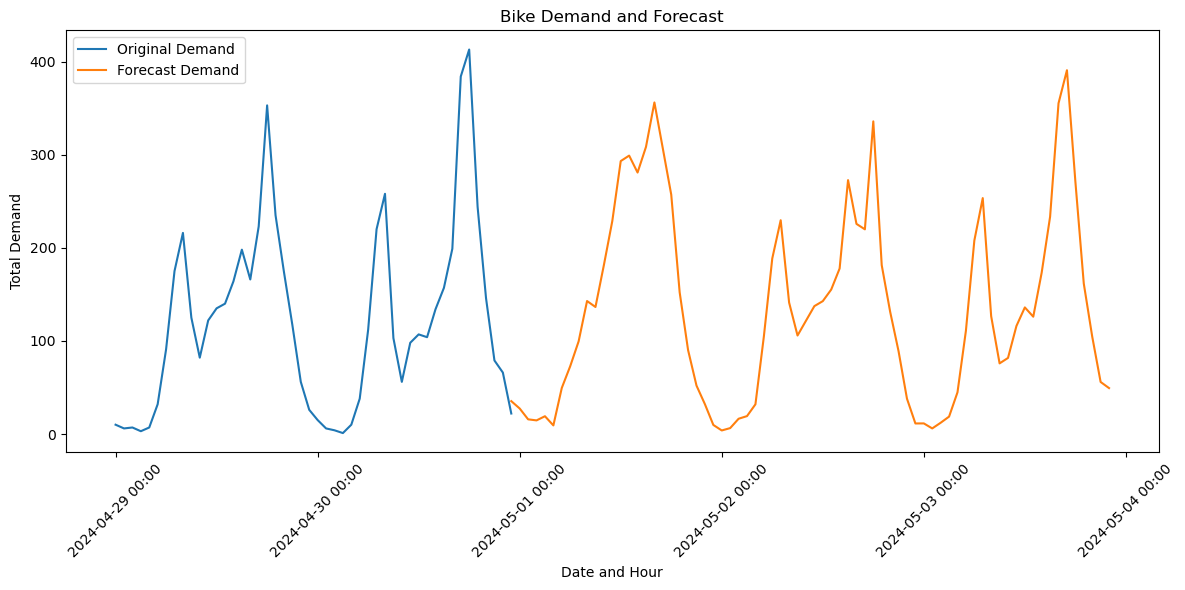

In [110]:
original['datetime'] = pd.to_datetime(original['datetime'])
df_forecast['datetime'] = pd.to_datetime(df_forecast['datetime'])


plt.figure(figsize=(12, 6))
sns.lineplot(x=original['datetime'], y=original['total_demand'], label='Original Demand')
sns.lineplot(x=df_forecast['datetime'], y=df_forecast['total_demand'], label='Forecast Demand')

# Format the x-axis to show both date and time
plt.xticks(rotation=45)  # Rotate the x-axis labels for better visibility
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H:%M'))

# Add titles and labels
plt.title('Bike Demand and Forecast')
plt.xlabel('Date and Hour')
plt.ylabel('Total Demand')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


The line graph depicts the actual bike demand (original demand) and the predicted bike demand (forecast demand) for a period from April 29th to May 4th, 2024. The forecast, likely generated using an LSTM model, closely tracks the actual demand, capturing the peaks and troughs in demand with reasonable accuracy.

### Training and Predictions

In [111]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size=0.2, random_state=42, shuffle=False)
print("Training set shape (X_train):", X_train.shape, "Training target shape (y_train):", y_train.shape)
print("Testing set shape (X_test):", X_test.shape, "Testing target shape (y_test):", y_test.shape)


Training set shape (X_train): (7565, 3, 8) Training target shape (y_train): (7565, 1)
Testing set shape (X_test): (1892, 3, 8) Testing target shape (y_test): (1892, 1)


In [112]:
train_predictions = modelLstm.predict(X_train)
test_predictions = modelLstm.predict(X_test)

60/60 [==============================] - 0s 2ms/step


In [113]:
train_predictions_inverse = scaler.inverse_transform(np.concatenate((train_predictions, np.zeros((train_predictions.shape[0], trainX.shape[2]-1))), axis=1))[:, 0]
y_train_actual = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((y_train.shape[0], trainX.shape[2]-1))), axis=1))[:, 0]

test_predictions_inverse = scaler.inverse_transform(np.concatenate((test_predictions, np.zeros((test_predictions.shape[0], trainX.shape[2]-1))), axis=1))[:, 0]
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], trainX.shape[2]-1))), axis=1))[:, 0]

In [114]:
# Training metrics
train_mse = mean_squared_error(y_train_actual, train_predictions_inverse)
train_mae = mean_absolute_error(y_train_actual, train_predictions_inverse)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, train_predictions_inverse)

# Testing metrics
test_mse = mean_squared_error(y_test_actual, test_predictions_inverse)
test_mae = mean_absolute_error(y_test_actual, test_predictions_inverse)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, test_predictions_inverse)

# Print metrics
print("Training Performance Metrics:")
print("Mean Absolute Error (MAE):", train_mae)
print("Mean Squared Error (MSE):", train_mse)
print("Root Mean Squared Error (RMSE):", train_rmse)
print("R² Score:", train_r2)

print("\nTesting Performance Metrics:")
print("Mean Absolute Error (MAE):", test_mae)
print("Mean Squared Error (MSE):", test_mse)
print("Root Mean Squared Error (RMSE):", test_rmse)
print("R² Score:", test_r2)


Training Performance Metrics:
Mean Absolute Error (MAE): 15.780762776703183
Mean Squared Error (MSE): 487.034252569294
Root Mean Squared Error (RMSE): 22.06885254310459
R² Score: 0.9501295165471997

Testing Performance Metrics:
Mean Absolute Error (MAE): 15.83956260678
Mean Squared Error (MSE): 563.0865134900874
Root Mean Squared Error (RMSE): 23.729444019826666
R² Score: 0.9137458009270585


The LSTM model shows strong performance, with a high R-squared of 0.95 on the training data, indicating a very good fit. The testing data R-squared of 0.93 suggests that the model generalizes well to new, unseen data. The Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) values are relatively low, indicating that the model's predictions are close to the actual values.

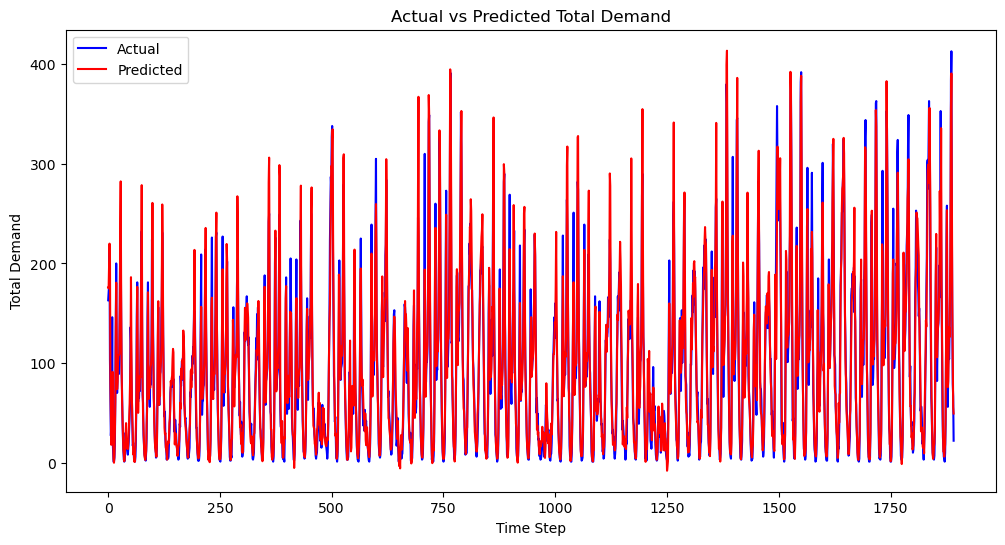

In [115]:
# Plot the results for the test set
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(test_predictions_inverse, label='Predicted', color='red')
plt.title('Actual vs Predicted Total Demand')
plt.xlabel('Time Step')
plt.ylabel('Total Demand')
plt.legend()
plt.show()

In [116]:
test_predictions_inverse.astype(int), y_test_actual.astype(int)

(array([175, 174, 199, ..., 104,  55,  49]),
 array([163, 171, 178, ...,  79,  66,  22]))

In [117]:
# Getting the first 24 values from both arrays
predicted_range = test_predictions_inverse[:10].astype(int)
actual_range = y_test_actual[:10].astype(int)

In [118]:
df = pd.DataFrame({
    'Actual Demand': actual_range,
    'Predicted Demand': predicted_range
})
df

,Actual Demand,Predicted Demand
0,163,175
1,171,174
2,178,199
3,215,219
4,103,205
5,61,80
6,27,49
7,37,17
8,61,27
9,146,48


## CitiBike Real Time Data

The Data is untrained and we are using the data from May 1 to May 3 to compare with our forecasted data.

In [119]:
file_path = 'JC-202405-citibike-tripdata.csv'
citiRealTimeData = pd.read_csv(file_path)
citiRealTimeData

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,CD89CCE98ED4A830,classic_bike,2024-05-27 13:48:06,2024-05-27 13:50:25,Madison St & 10 St,HB503,7 St & Monroe St,HB304,40.749943,-74.035865,40.746413,-74.037977,member
1,D6AE40DD78B49217,classic_bike,2024-05-22 20:10:50,2024-05-22 20:22:13,Madison St & 10 St,HB503,South Waterfront Walkway - Sinatra Dr & 1 St,HB103,40.749943,-74.035865,40.736982,-74.027781,member
2,39FDE65AAE7A4A22,electric_bike,2024-05-22 16:53:00,2024-05-22 17:12:58,Clinton St & 7 St,HB303,Columbus Drive,JC014,40.745420,-74.033411,40.718355,-74.038914,member
3,B39B432803AA828B,electric_bike,2024-05-19 09:22:01,2024-05-19 09:30:02,Jersey & 6th St,JC027,Columbus Drive,JC014,40.725227,-74.045349,40.718355,-74.038914,member
4,0B7EE5E35F5BC47D,electric_bike,2024-05-10 19:59:35,2024-05-10 20:10:13,Jersey & 6th St,JC027,Columbus Drive,JC014,40.725218,-74.045337,40.718355,-74.038914,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97474,6F85427F9A277AD3,electric_bike,2024-05-29 07:22:54,2024-05-29 07:31:04,Southwest Park - Jackson St & Observer Hwy,HB401,Journal Square,JC103,40.737708,-74.041646,40.733670,-74.062500,member
97475,2949ECAA9F1EAA0D,electric_bike,2024-05-08 07:27:16,2024-05-08 07:36:16,Southwest Park - Jackson St & Observer Hwy,HB401,Journal Square,JC103,40.737551,-74.041664,40.733670,-74.062500,member
97476,A4B89475534E8031,electric_bike,2024-05-17 07:00:09,2024-05-17 07:06:57,Southwest Park - Jackson St & Observer Hwy,HB401,Journal Square,JC103,40.737618,-74.041690,40.733670,-74.062500,member
97477,9842800FFD9EAC19,classic_bike,2024-05-10 18:06:46,2024-05-10 18:18:54,Hamilton Park,JC009,Journal Square,JC103,40.727596,-74.044247,40.733670,-74.062500,member


In [120]:
citiRealTimeData['started_at'] = pd.to_datetime(citiRealTimeData['started_at'])
citiRealTimeData['started_at_hour'] = citiRealTimeData['started_at'].dt.floor('H')

citiRealTimeData

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,started_at_hour
0,CD89CCE98ED4A830,classic_bike,2024-05-27 13:48:06,2024-05-27 13:50:25,Madison St & 10 St,HB503,7 St & Monroe St,HB304,40.749943,-74.035865,40.746413,-74.037977,member,2024-05-27 13:00:00
1,D6AE40DD78B49217,classic_bike,2024-05-22 20:10:50,2024-05-22 20:22:13,Madison St & 10 St,HB503,South Waterfront Walkway - Sinatra Dr & 1 St,HB103,40.749943,-74.035865,40.736982,-74.027781,member,2024-05-22 20:00:00
2,39FDE65AAE7A4A22,electric_bike,2024-05-22 16:53:00,2024-05-22 17:12:58,Clinton St & 7 St,HB303,Columbus Drive,JC014,40.745420,-74.033411,40.718355,-74.038914,member,2024-05-22 16:00:00
3,B39B432803AA828B,electric_bike,2024-05-19 09:22:01,2024-05-19 09:30:02,Jersey & 6th St,JC027,Columbus Drive,JC014,40.725227,-74.045349,40.718355,-74.038914,member,2024-05-19 09:00:00
4,0B7EE5E35F5BC47D,electric_bike,2024-05-10 19:59:35,2024-05-10 20:10:13,Jersey & 6th St,JC027,Columbus Drive,JC014,40.725218,-74.045337,40.718355,-74.038914,member,2024-05-10 19:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97474,6F85427F9A277AD3,electric_bike,2024-05-29 07:22:54,2024-05-29 07:31:04,Southwest Park - Jackson St & Observer Hwy,HB401,Journal Square,JC103,40.737708,-74.041646,40.733670,-74.062500,member,2024-05-29 07:00:00
97475,2949ECAA9F1EAA0D,electric_bike,2024-05-08 07:27:16,2024-05-08 07:36:16,Southwest Park - Jackson St & Observer Hwy,HB401,Journal Square,JC103,40.737551,-74.041664,40.733670,-74.062500,member,2024-05-08 07:00:00
97476,A4B89475534E8031,electric_bike,2024-05-17 07:00:09,2024-05-17 07:06:57,Southwest Park - Jackson St & Observer Hwy,HB401,Journal Square,JC103,40.737618,-74.041690,40.733670,-74.062500,member,2024-05-17 07:00:00
97477,9842800FFD9EAC19,classic_bike,2024-05-10 18:06:46,2024-05-10 18:18:54,Hamilton Park,JC009,Journal Square,JC103,40.727596,-74.044247,40.733670,-74.062500,member,2024-05-10 18:00:00


In [121]:
# Grouping by 'started_at_hour' and counting the number of rides per hour
total_demand_per_hour = citiRealTimeData.groupby('started_at_hour').size().reset_index(name='total_demand')
total_demand_per_hour

,started_at_hour,total_demand
0,2024-05-01 00:00:00,11
1,2024-05-01 01:00:00,7
2,2024-05-01 02:00:00,4
3,2024-05-01 03:00:00,3
4,2024-05-01 04:00:00,6
...,...,...
737,2024-05-31 19:00:00,307
738,2024-05-31 20:00:00,230
739,2024-05-31 21:00:00,201
740,2024-05-31 22:00:00,138


In [122]:
# Filtering for the dates 2024-05-02 and 2024-05-03
filtered_data = total_demand_per_hour[
    (total_demand_per_hour['started_at_hour'] >= '2024-05-02 00:00:00') &
    (total_demand_per_hour['started_at_hour'] < '2024-05-04 00:00:00')
]
filtered_data

,started_at_hour,total_demand
24,2024-05-02 00:00:00,14
25,2024-05-02 01:00:00,4
26,2024-05-02 02:00:00,7
27,2024-05-02 03:00:00,1
28,2024-05-02 04:00:00,7
29,2024-05-02 05:00:00,36
30,2024-05-02 06:00:00,123
31,2024-05-02 07:00:00,199
32,2024-05-02 08:00:00,267
33,2024-05-02 09:00:00,107


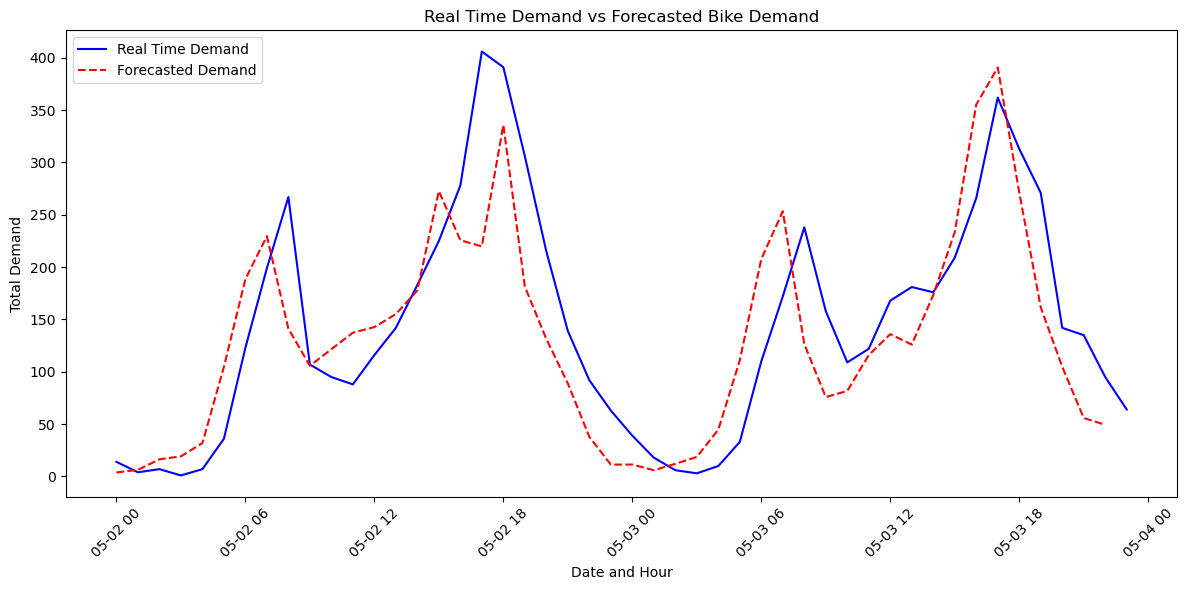

In [123]:
# Filtering the forecast data to start from '2024-05-02 00:00:00'
df_forecast_filtered = df_forecast[df_forecast['datetime'] >= '2024-05-02 00:00:00']


plt.figure(figsize=(12, 6))
plt.plot(filtered_data['started_at_hour'], filtered_data['total_demand'], label='Real Time Demand', color='blue')
plt.plot(df_forecast_filtered['datetime'], df_forecast_filtered['total_demand'], label='Forecasted Demand', color='red', linestyle='--')
plt.xlabel('Date and Hour')
plt.ylabel('Total Demand')
plt.title('Real Time Demand vs Forecasted Bike Demand')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The line graph compares real-time bike demand with forecasted demand over a few days. The blue line represents the actual demand, while the red dashed line shows the predicted demand. Overall, the forecast captures the general trend of demand, with peaks and valleys aligning reasonably well with the actual demand. However, there are instances where the forecast overestimates or underestimates demand, particularly during peak periods.

# **Conclusion**

### Model Performance Insights

- Including **weather features** like **temperature**, **humidity**, **precipitation**, **dew**, **solar radiation**, and **windspeed** led to **significant improvements** in prediction accuracy, as shown by **higher R-squared values** and **lower MSE** and **MAE scores**.

- **Ensemble methods** such as **Gradient Boosting** and **Random Forest** consistently **outperformed baseline models** like **Linear Regression** and **KNN**, demonstrating their ability to capture **complex patterns** in the data.

- **Advanced models**, especially **LSTM**, achieved the **highest accuracy**, particularly in **time-series data**, with **R-squared values exceeding 0.90** for the **Citi Bike datasets**.

